# Dynamics: CESM3 / MOM6 experiment comparison

Diagnostics of the ocean *dynamics* and of the buoyancy / momentum
parameterizations, for a set of coupled and forced experiments. The shared
`Experiment` class lives in `experiment.py` so it can be reused across
notebooks.

**Experiments compared**

| name | mode | data folder |
|------|------|-------------|
| `CTRL` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0` | coupled | `data/coupled_55years` |
| `coupled_bANN_1.0_uANN_1.0` | coupled | `data/coupled_55years` |
| `forced_CTRL` | forced | `data/forced_55years` |
| `forced_bANN_1.0` | forced | `data/forced_55years` |
| `forced_bANN_1.0_uANN_1.0` | forced | `data/forced_55years` |

**Figures**

1. Surface isopycnal (Redi) tracer diffusivity `diftrelo`.
2. Parameterized (GM) overturning streamfunction at 1000 m (global maps).
3. APE dissipation by the buoyancy parameterization `MEKE_GM_src`.
4. Energy injection by the ZB2020 momentum scheme in `forced_bANN_1.0_uANN_1.0`.

Heavy quantities are computed once through the `Experiment` class (methods
`compute_*`, reading the raw model history) and cached as
`<folder>/<name>_<metric>.nc`; the plotting cells only read those files.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean

from experiment import Experiment

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 18})

# Repo-root-relative paths (this notebook lives in <repo>/notebooks)
REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
COUPLED_DIR = os.path.join(REPO, 'data', 'coupled_55years')
FORCED_DIR = os.path.join(REPO, 'data', 'forced_55years')
FIG_DIR = os.path.join(REPO, 'figures', 'coupled_55years')

print('REPO       =', REPO)
print('YAML_DIR   =', YAML_DIR)
print('COUPLED_DIR=', COUPLED_DIR)
print('FORCED_DIR =', FORCED_DIR)

REPO       = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
YAML_DIR   = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/yamls
COUPLED_DIR= /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/coupled_55years
FORCED_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/forced_55years


## Initialize experiments (read-only)

Each experiment is defined by its `name`, the diagnostics YAML config, and the
folder holding its postprocessed NetCDF files. Initialization is read-only: it
only reads config + (best-effort) grid, and never triggers heavy computation.

In [3]:
# (name, folder) for each experiment. YAML config is yamls/<name>.yaml
experiment_defs = [
    ('CTRL',                        COUPLED_DIR),
    ('coupled_bANN_1.0',            COUPLED_DIR),
    ('coupled_bANN_1.0_uANN_1.0',   COUPLED_DIR),
    ('forced_CTRL',                 FORCED_DIR),
    ('forced_bANN_1.0',             FORCED_DIR),
    ('forced_bANN_1.0_uANN_1.0',    FORCED_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

exp_names = list(exps.keys())
print('\nInitialized:', exp_names)

[CTRL] casename=CTRL, rundir=/glade/derecho/scratch/jiarongw/CTRL/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 

[coupled_bANN_1.0] casename=coupled_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0/run
MOM6 grid successfully loaded... 

[coupled_bANN_1.0_uANN_1.0] casename=coupled_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/coupled_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 

[forced_CTRL] casename=forced_CTRL, rundir=/glade/derecho/scratch/pavelp/forced_CTRL/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0] casename=forced_bANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0/run
MOM6 grid successfully loaded... 

[forced_bANN_1.0_uANN_1.0] casename=forced_bANN_1.0_uANN_1.0, rundir=/glade/derecho/scratch/pavelp/forced_bANN_1.0_uANN_1.0/run
MOM6 grid successfully loaded... 


Initialized: ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0', 'forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']


In [4]:
# Column order: GM (left), bANN (center), bANN_uANN (right)
coupled_names = ['CTRL', 'coupled_bANN_1.0', 'coupled_bANN_1.0_uANN_1.0']
forced_names = ['forced_CTRL', 'forced_bANN_1.0', 'forced_bANN_1.0_uANN_1.0']

In [5]:
# Short legend labels (regime is shown in the panel title, so it is omitted here)
LABELS = {
    'CTRL':                       'GM',
    'coupled_bANN_1.0':           'bANN',
    'coupled_bANN_1.0_uANN_1.0':  'bANN_uANN',
    'forced_CTRL':                'GM',
    'forced_bANN_1.0':            'bANN',
    'forced_bANN_1.0_uANN_1.0':   'bANN_uANN',
}

# 1. Surface isopycnal (Redi) diffusivity

Horizontal maps of the surface epineutral tracer diffusivity `diftrelo`
(Ocean Tracer Epineutral Laplacian Diffusivity, m^2 s^-1), time-averaged over
model years 50-54 (surface interface, zi = 0 m). This is the isopycnal (Redi)
diffusivity applied by the tracer-mixing scheme, useful for contrasting the GM
control against the (b)ANN parameterizations.

The first cell computes and caches the surface field to
`<folder>/<name>_diftrelo_surface.nc` (heavy: reads the raw native history for
each experiment; experiments already cached, or without native output, are
skipped). The second cell plots them.

In [ ]:
# Compute (and cache) the time-mean surface epineutral diffusivity for every
# experiment. Reads raw native history -> heavy step; skips any experiment
# already cached (or without native output on disk).
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_diftrelo_surface()
    except Exception:
        print(f'{name} skipped')

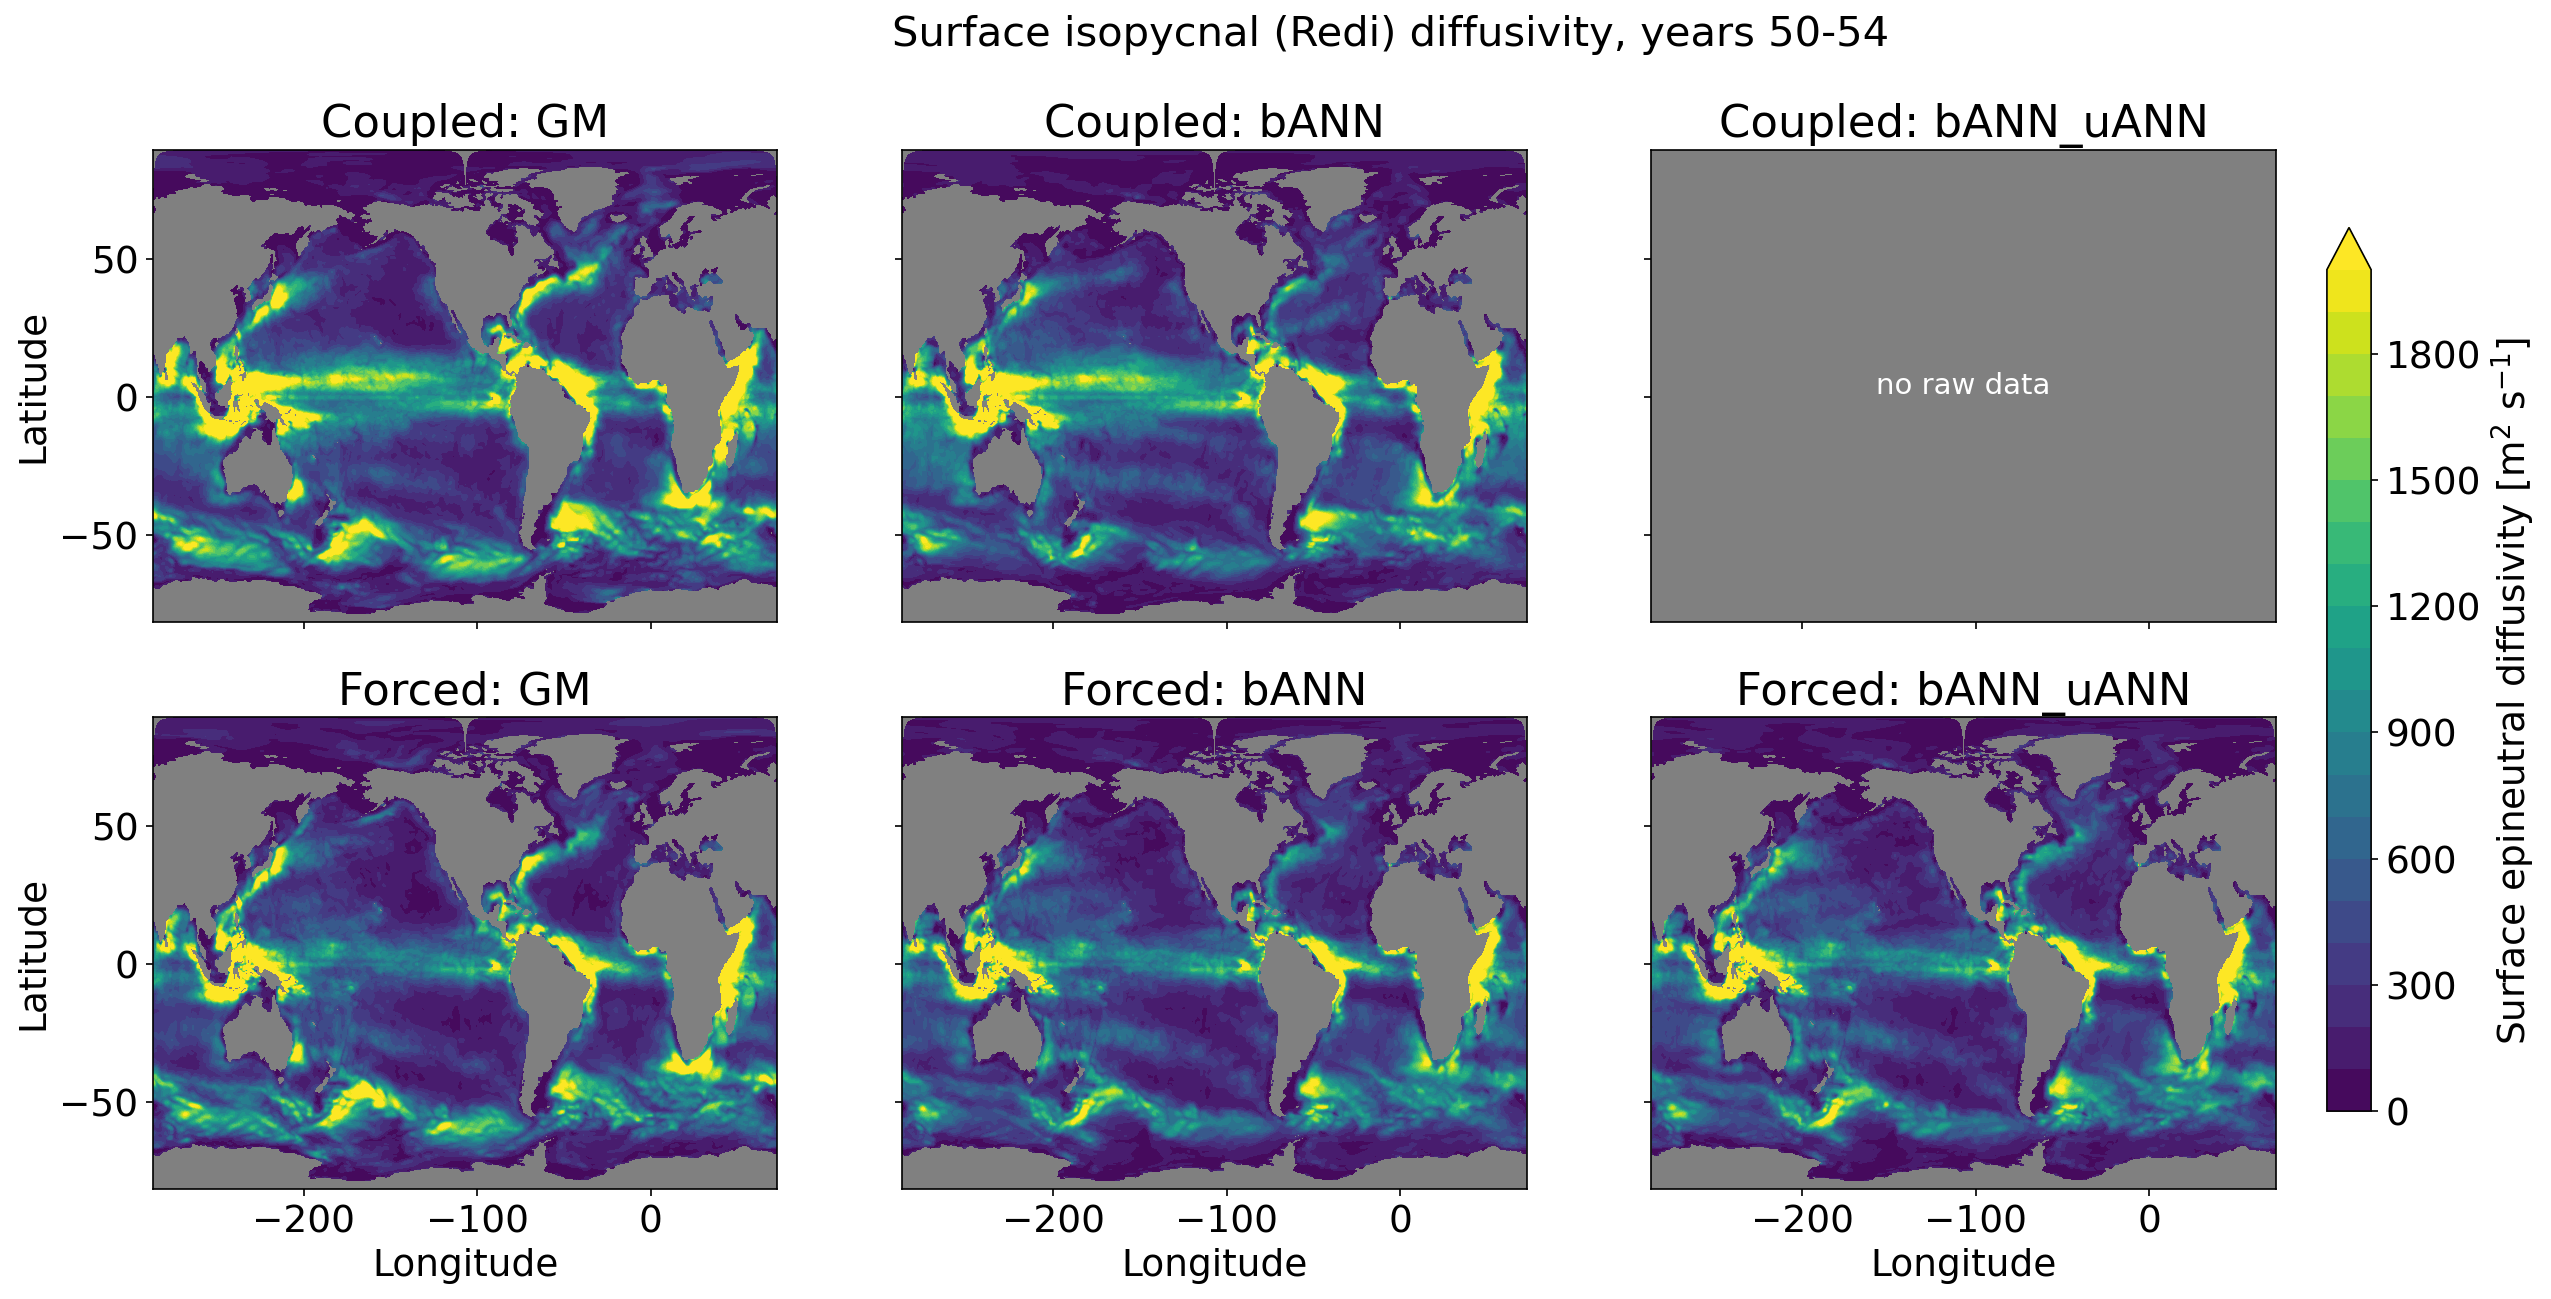

In [19]:
# Surface epineutral (Redi) diffusivity maps: 2x3 grid
# (coupled top / forced bottom). Plotted on the curvilinear (geolon, geolat)
# grid so the tripolar cap is rendered correctly.
DIFF_LEVELS = np.arange(0, 2001, 100)   # m^2 s^-1

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            field = exps[name].diftrelo_surface()
            grd = exps[name].grd
            cf = ax.contourf(grd.geolon, grd.geolat, field, levels=DIFF_LEVELS,
                             cmap='viridis', extend='max')
            ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
            ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'Surface epineutral diffusivity [m$^2$ s$^{-1}$]',
                 extend='max', shrink=0.85, pad=0.02)
fig.suptitle(r'Surface isopycnal (Redi) diffusivity, years 50-54', fontsize=20)
plt.show()

# 2. Parameterized (GM) overturning at 1000 m

Global maps of the *parameterized* (GM) overturning streamfunction at 1000 m
depth. For each experiment the parameterized meridional bolus transport `vhGM`
(kg s^-1) is read from the z-coordinate history (`*.mom6.h.z.*`), averaged over
the standard window, converted to Sv and vertically accumulated from the bottom
to give a local overturning streamfunction; the layer nearest 1000 m is plotted
(see `spatial_overturning.ipynb`).

The first cell computes and caches each map to
`<folder>/<name>_gm_overturning_1km.nc`; the second plots the six experiments.

In [20]:
# Compute (and cache) the parameterized GM overturning at 1 km for every
# experiment. Reads raw z-coordinate history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_gm_overturning_1km()
    except Exception as e:
        print(f'{name} skipped ({e})')

[########################################] | 100% Completed | 45.66 s
[########################################] | 100% Completed | 45.42 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 46.42 s
[########################################] | 100% Completed | 45.36 s
[########################################] | 100% Completed | 47.98 s


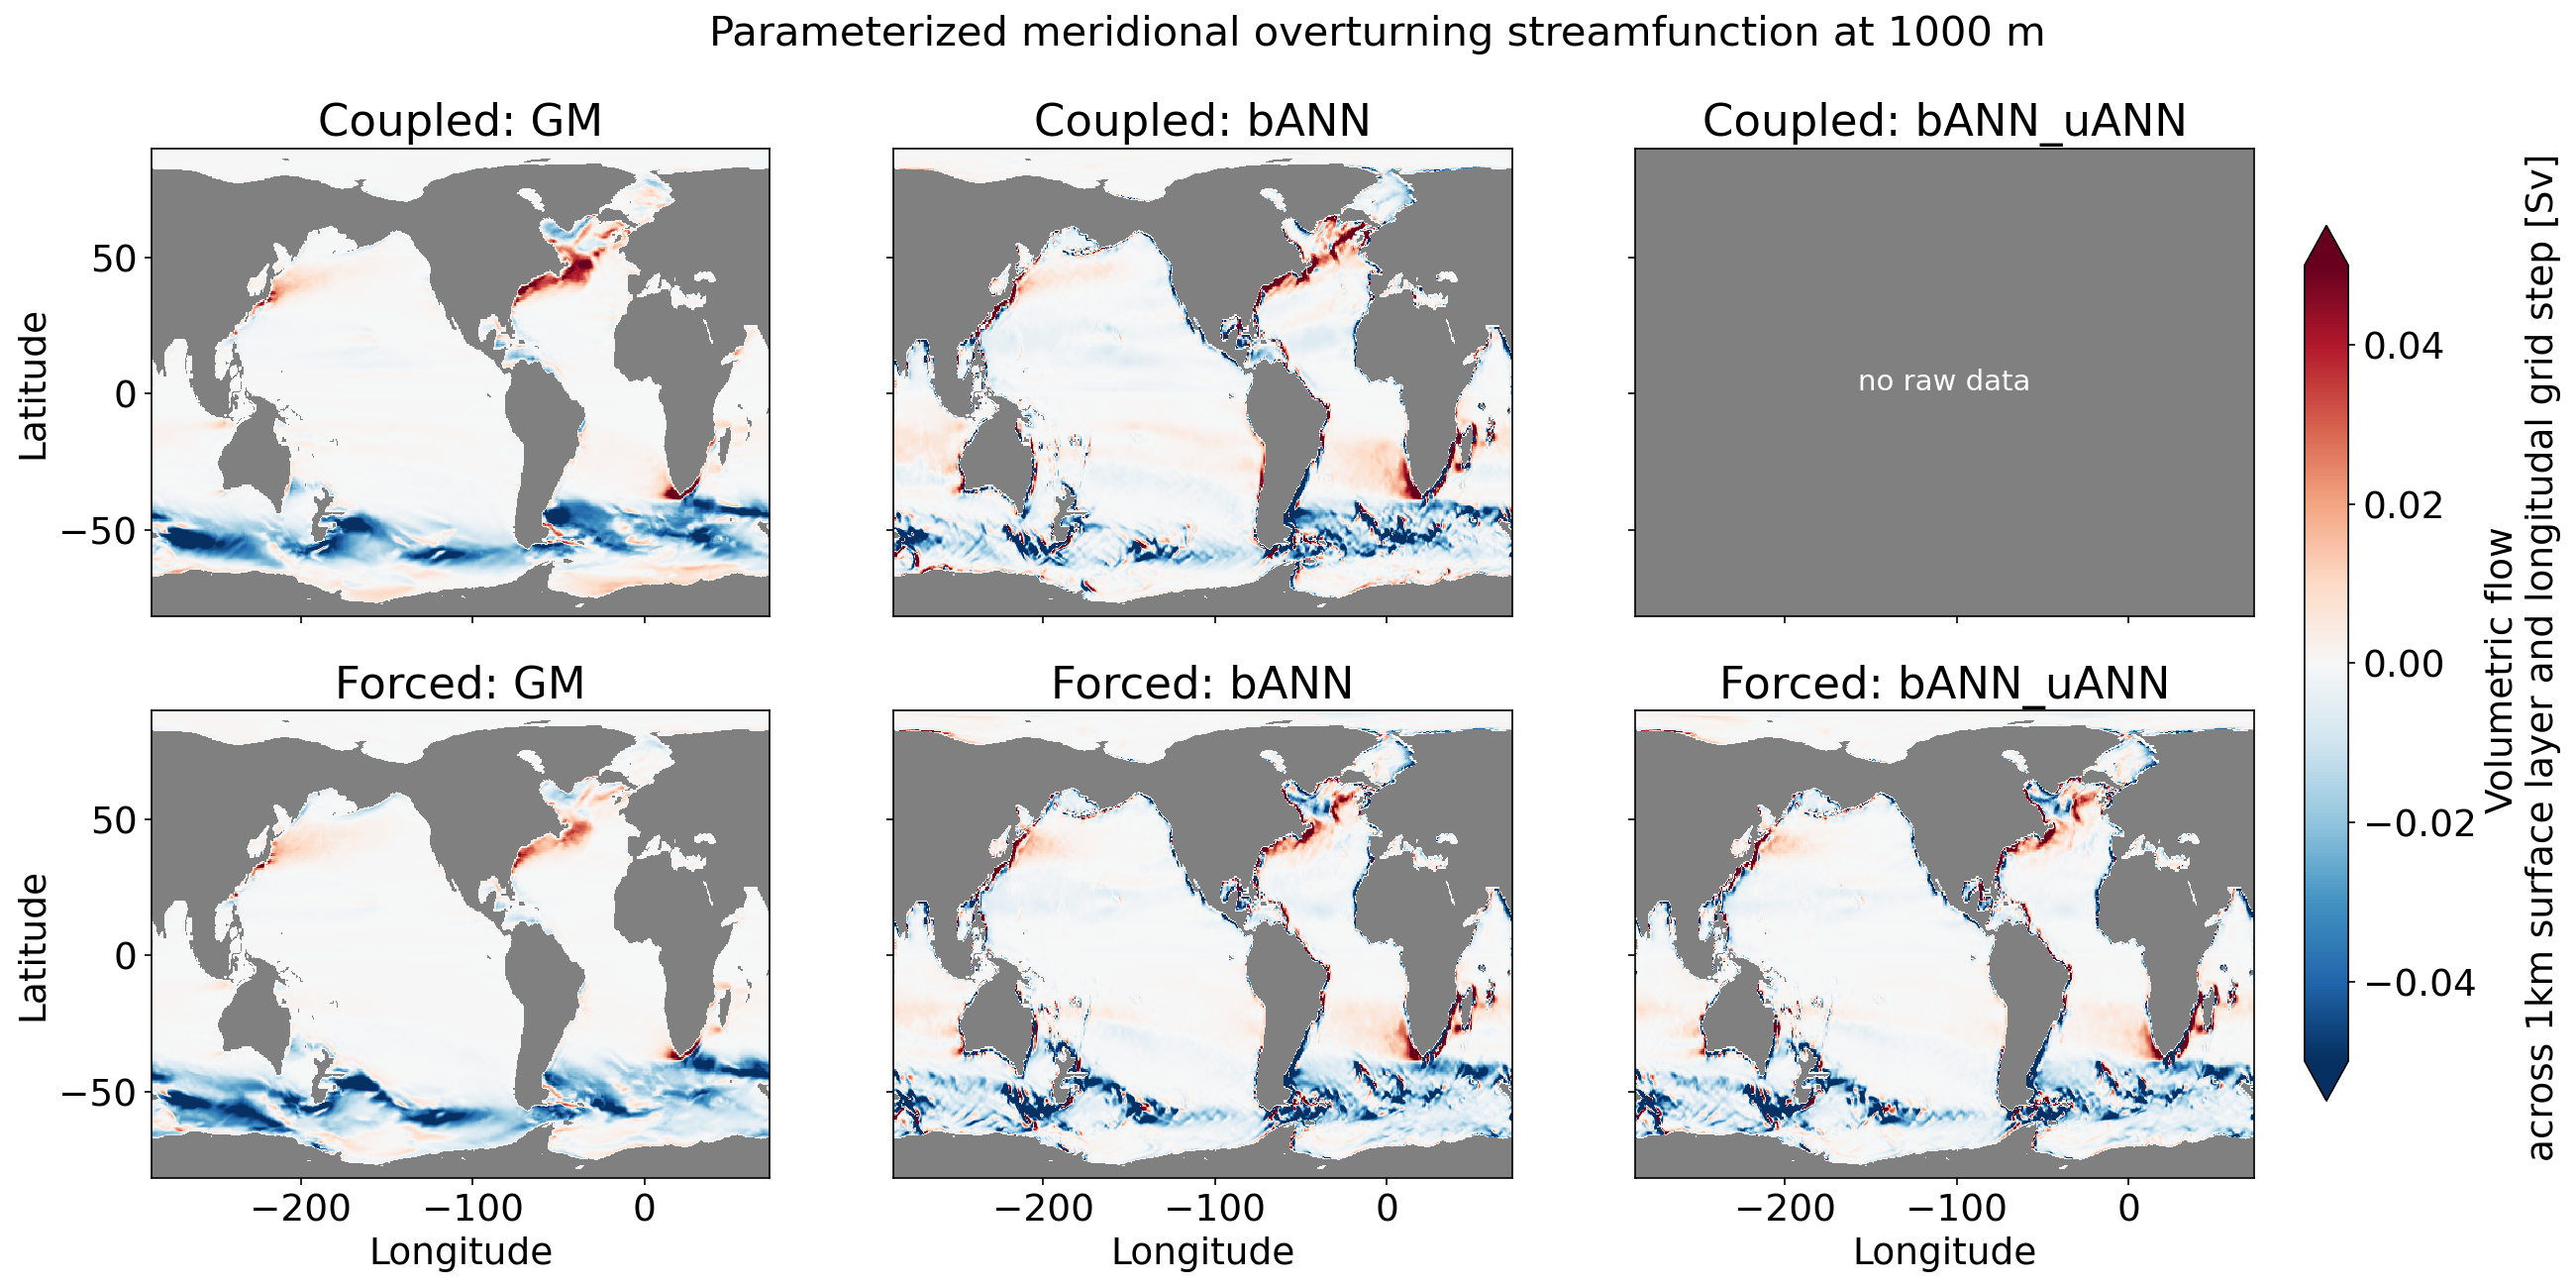

In [37]:
# Parameterized GM overturning at 1 km: 2x3 global maps (coupled / forced).
PSI_LIM = 0.05   # Sv

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
pm = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            ds = exps[name].gm_overturning_1km()
            pm = ax.pcolormesh(ds.geolonv, ds.geolatv, ds.psi_gm_1km,
                               cmap='RdBu_r', vmin=-PSI_LIM, vmax=PSI_LIM,
                               shading='auto')
            ax.set_xlim(float(ds.geolonv.min()), float(ds.geolonv.max()))
            ax.set_ylim(float(ds.geolatv.min()), float(ds.geolatv.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
        #ax.set_ylim([20,70])
        #ax.set_xlim([-80,0])
if pm is not None:
    fig.colorbar(pm, ax=axes, label='Volumetric flow \n across 1km surface layer and longitudal grid step [Sv]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'Parameterized meridional overturning streamfunction at 1000 m',
             fontsize=20)
plt.show()

# 3. APE dissipation by the buoyancy parameterization

Time-mean maps of `MEKE_GM_src` (W m^-2), the source of mesoscale eddy kinetic
energy extracted from the available potential energy by the GM / MEKE buoyancy
parameterization (see the `MEKE_GM_src` maps in
[compare_runs_coupled.ipynb](../notebooks-development/compare_runs_coupled.ipynb)).
It is already a vertically-integrated 2-D field in the native output.

The first cell computes and caches each map to
`<folder>/<name>_meke_gm_src.nc`; the second plots the six experiments.

In [8]:
# Compute (and cache) the time-mean MEKE_GM_src for every experiment.
# Reads raw native history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_meke_gm_src()
    except Exception as e:
        print(f'{name} skipped ({e})')

CTRL skipped ('MEKE_GM_src')
[########################################] | 100% Completed | 43.15 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 50.01 s
[########################################] | 100% Completed | 48.65 s
[########################################] | 100% Completed | 53.66 s


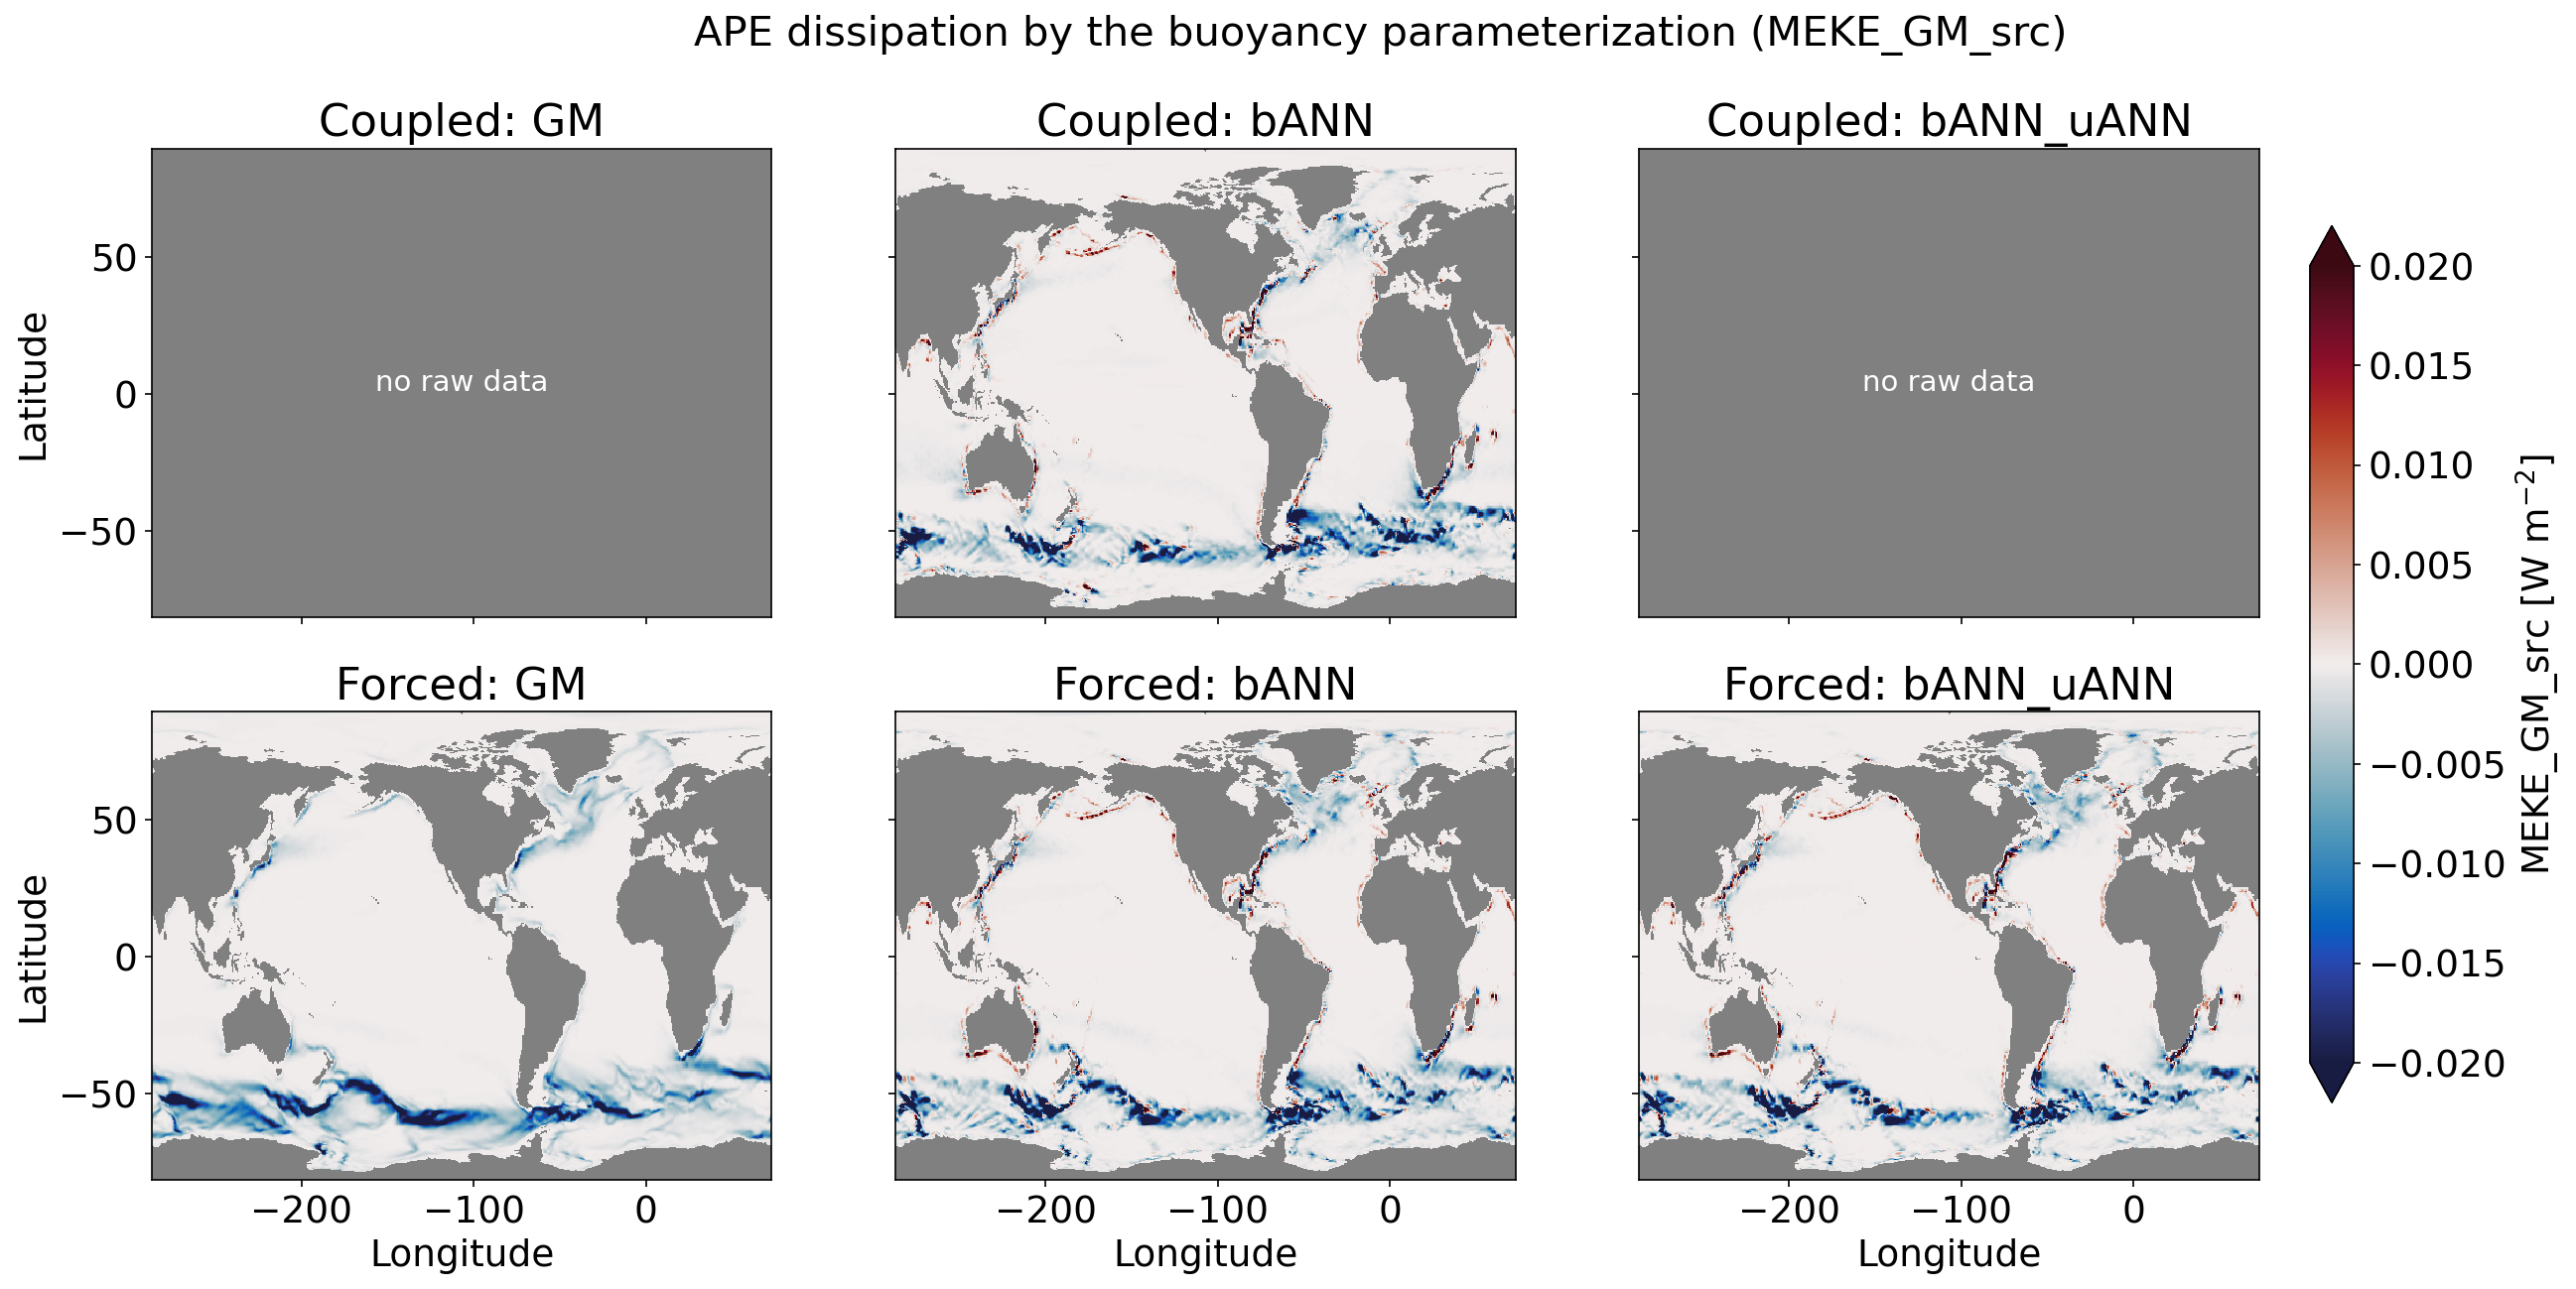

In [38]:
# APE dissipation MEKE_GM_src: 2x3 maps (coupled / forced).
MEKE_LIM = 0.02   # W m^-2

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
pm = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            field = exps[name].meke_gm_src()
            grd = exps[name].grd
            pm = ax.pcolormesh(grd.geolon, grd.geolat, field,
                               cmap=cmocean.cm.balance,
                               vmin=-MEKE_LIM, vmax=MEKE_LIM, shading='auto')
            ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
            ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if pm is not None:
    fig.colorbar(pm, ax=axes, label=r'MEKE_GM_src [W m$^{-2}$]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'APE dissipation by the buoyancy parameterization (MEKE_GM_src)',
             fontsize=20)
plt.show()

# 4. Energy injection by the uANN momentum scheme

Single-panel map of where the ZB2020 momentum parameterization injects energy in
`forced_bANN_1.0_uANN_1.0`. The column-integrated energy-injection rate is
`rho0 * KE_ZB2020.sum('z_l')` with `rho0 = 1023` kg m^-3, giving W m^-2, where
`KE_ZB2020` (m^3 s^-3) is read from the z-coordinate history (`*.mom6.h.z.*`)
and time-averaged over the standard window.

The first cell computes and caches the map to
`<folder>/<name>_ke_zb2020_vertsum.nc`; the second plots it.

In [ ]:
# Compute (and cache) the vertically-integrated ZB2020 energy injection for
# the momentum-flux experiment. Reads raw z-coordinate history -> heavy.
ZB_NAME = 'forced_bANN_1.0_uANN_1.0'
try:
    exps[ZB_NAME].compute_ke_zb2020_vertsum()
except Exception as e:
    print(f'{ZB_NAME} skipped ({e})')

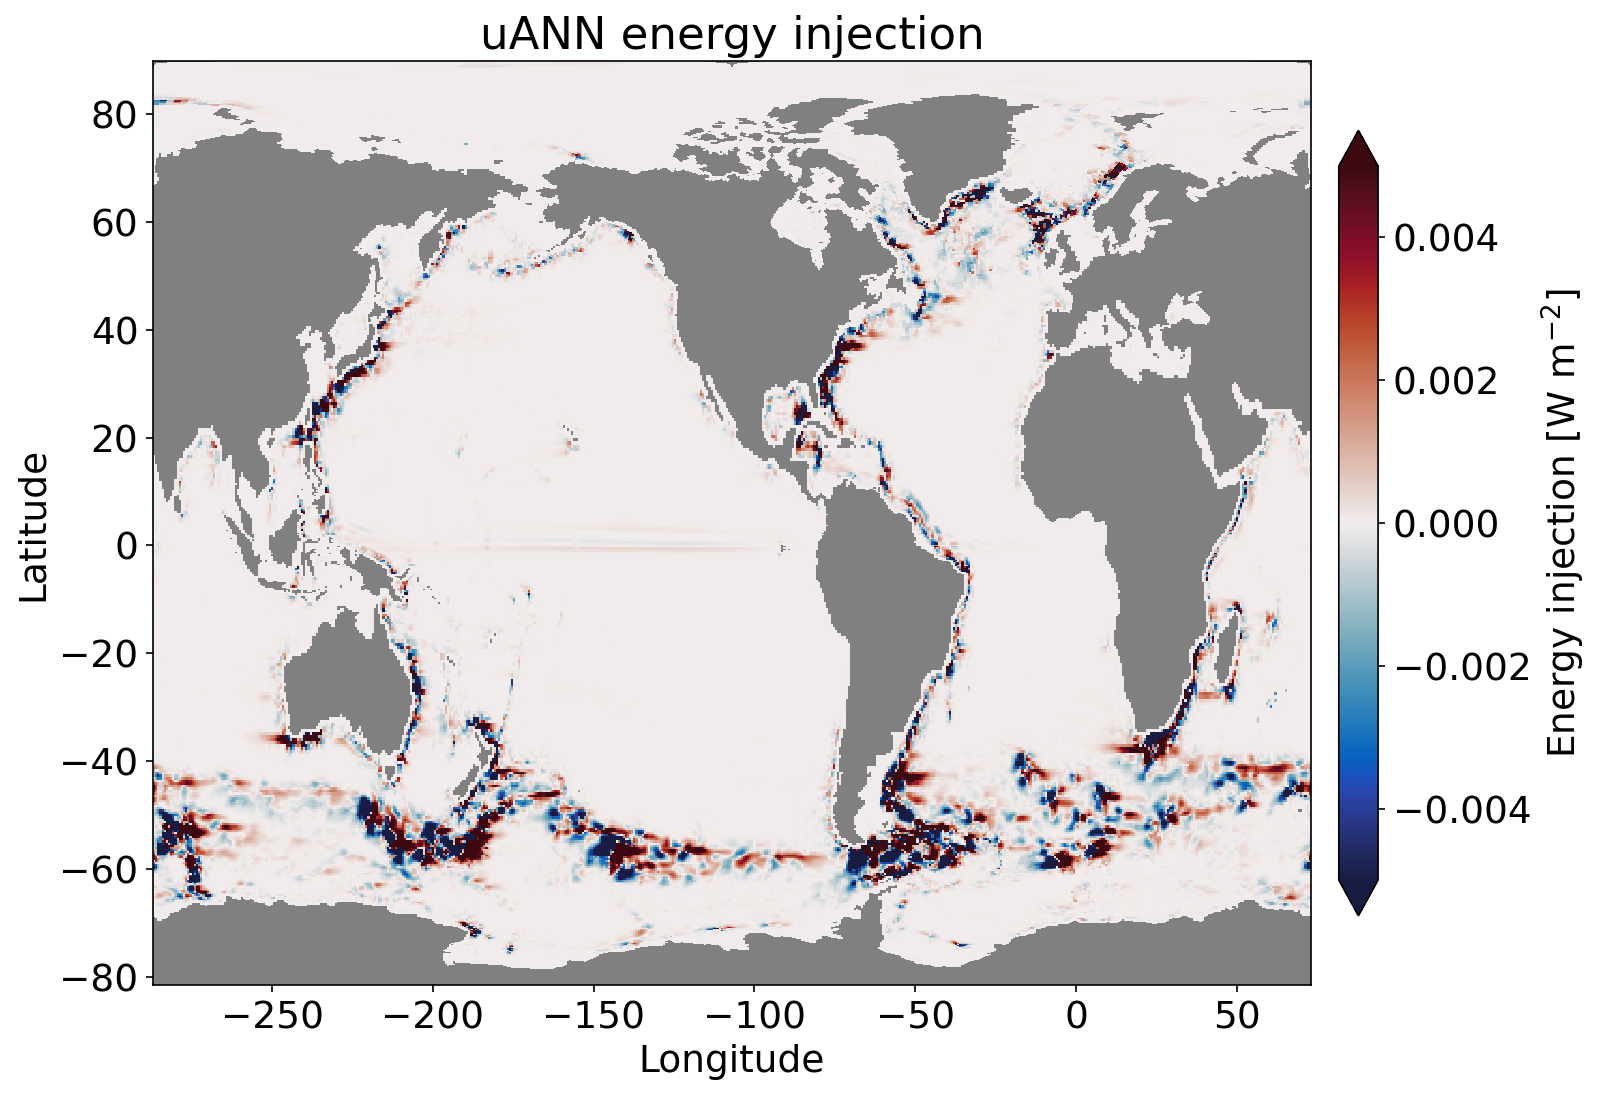

In [54]:
# ZB2020 energy injection: single-panel map.
field = exps[ZB_NAME].ke_zb2020_vertsum()
grd = exps[ZB_NAME].grd

#lim = float(np.nanpercentile(np.abs(field.values), 99))
lim=0.005

fig, ax = plt.subplots(figsize=(12, 8), dpi=150)
ax.set_facecolor('gray')
pm = ax.pcolormesh(grd.geolon, grd.geolat, field,
                   cmap=cmocean.cm.balance, vmin=-lim, vmax=lim, shading='auto')
ax.set_xlim(float(grd.geolon.min()), float(grd.geolon.max()))
ax.set_ylim(float(grd.geolat.min()), float(grd.geolat.max()))
fig.colorbar(pm, ax=ax, label=r'Energy injection [W m$^{-2}$]',
             extend='both', shrink=0.85, pad=0.02)
ax.set_title(f'uANN energy injection')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.show()

# 5. Barotropic (depth-integrated) streamfunction

Global maps of the barotropic streamfunction, following the CDFtools algorithm:
the depth-integrated zonal transport `umo` (kg s^-1, read from the z-coordinate
history `*.mom6.h.z.*`) is summed over depth and cumulatively integrated in the
meridional direction from the South Pole, then converted to Sv. The
streamfunction lives on the cell corner (`yq`, `xq`) and is offset to zero over
the Americas (xq=-80, yq=40) for convenient plotting.

The first cell computes and caches each map to
`<folder>/<name>_barotropic_streamfunction.nc`; the second plots the six
experiments. The colour range is capped at ±60 Sv so the subtropical gyres are
resolved (the ACC saturates).

In [66]:
# Compute (and cache) the barotropic streamfunction for every experiment.
# Reads raw z-coordinate history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_barotropic_streamfunction()
    except Exception as e:
        print(f'{name} skipped ({e})')

[########################################] | 100% Completed | 49.90 s
[########################################] | 100% Completed | 51.51 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 49.31 s
[########################################] | 100% Completed | 49.80 s
[########################################] | 100% Completed | 52.12 s


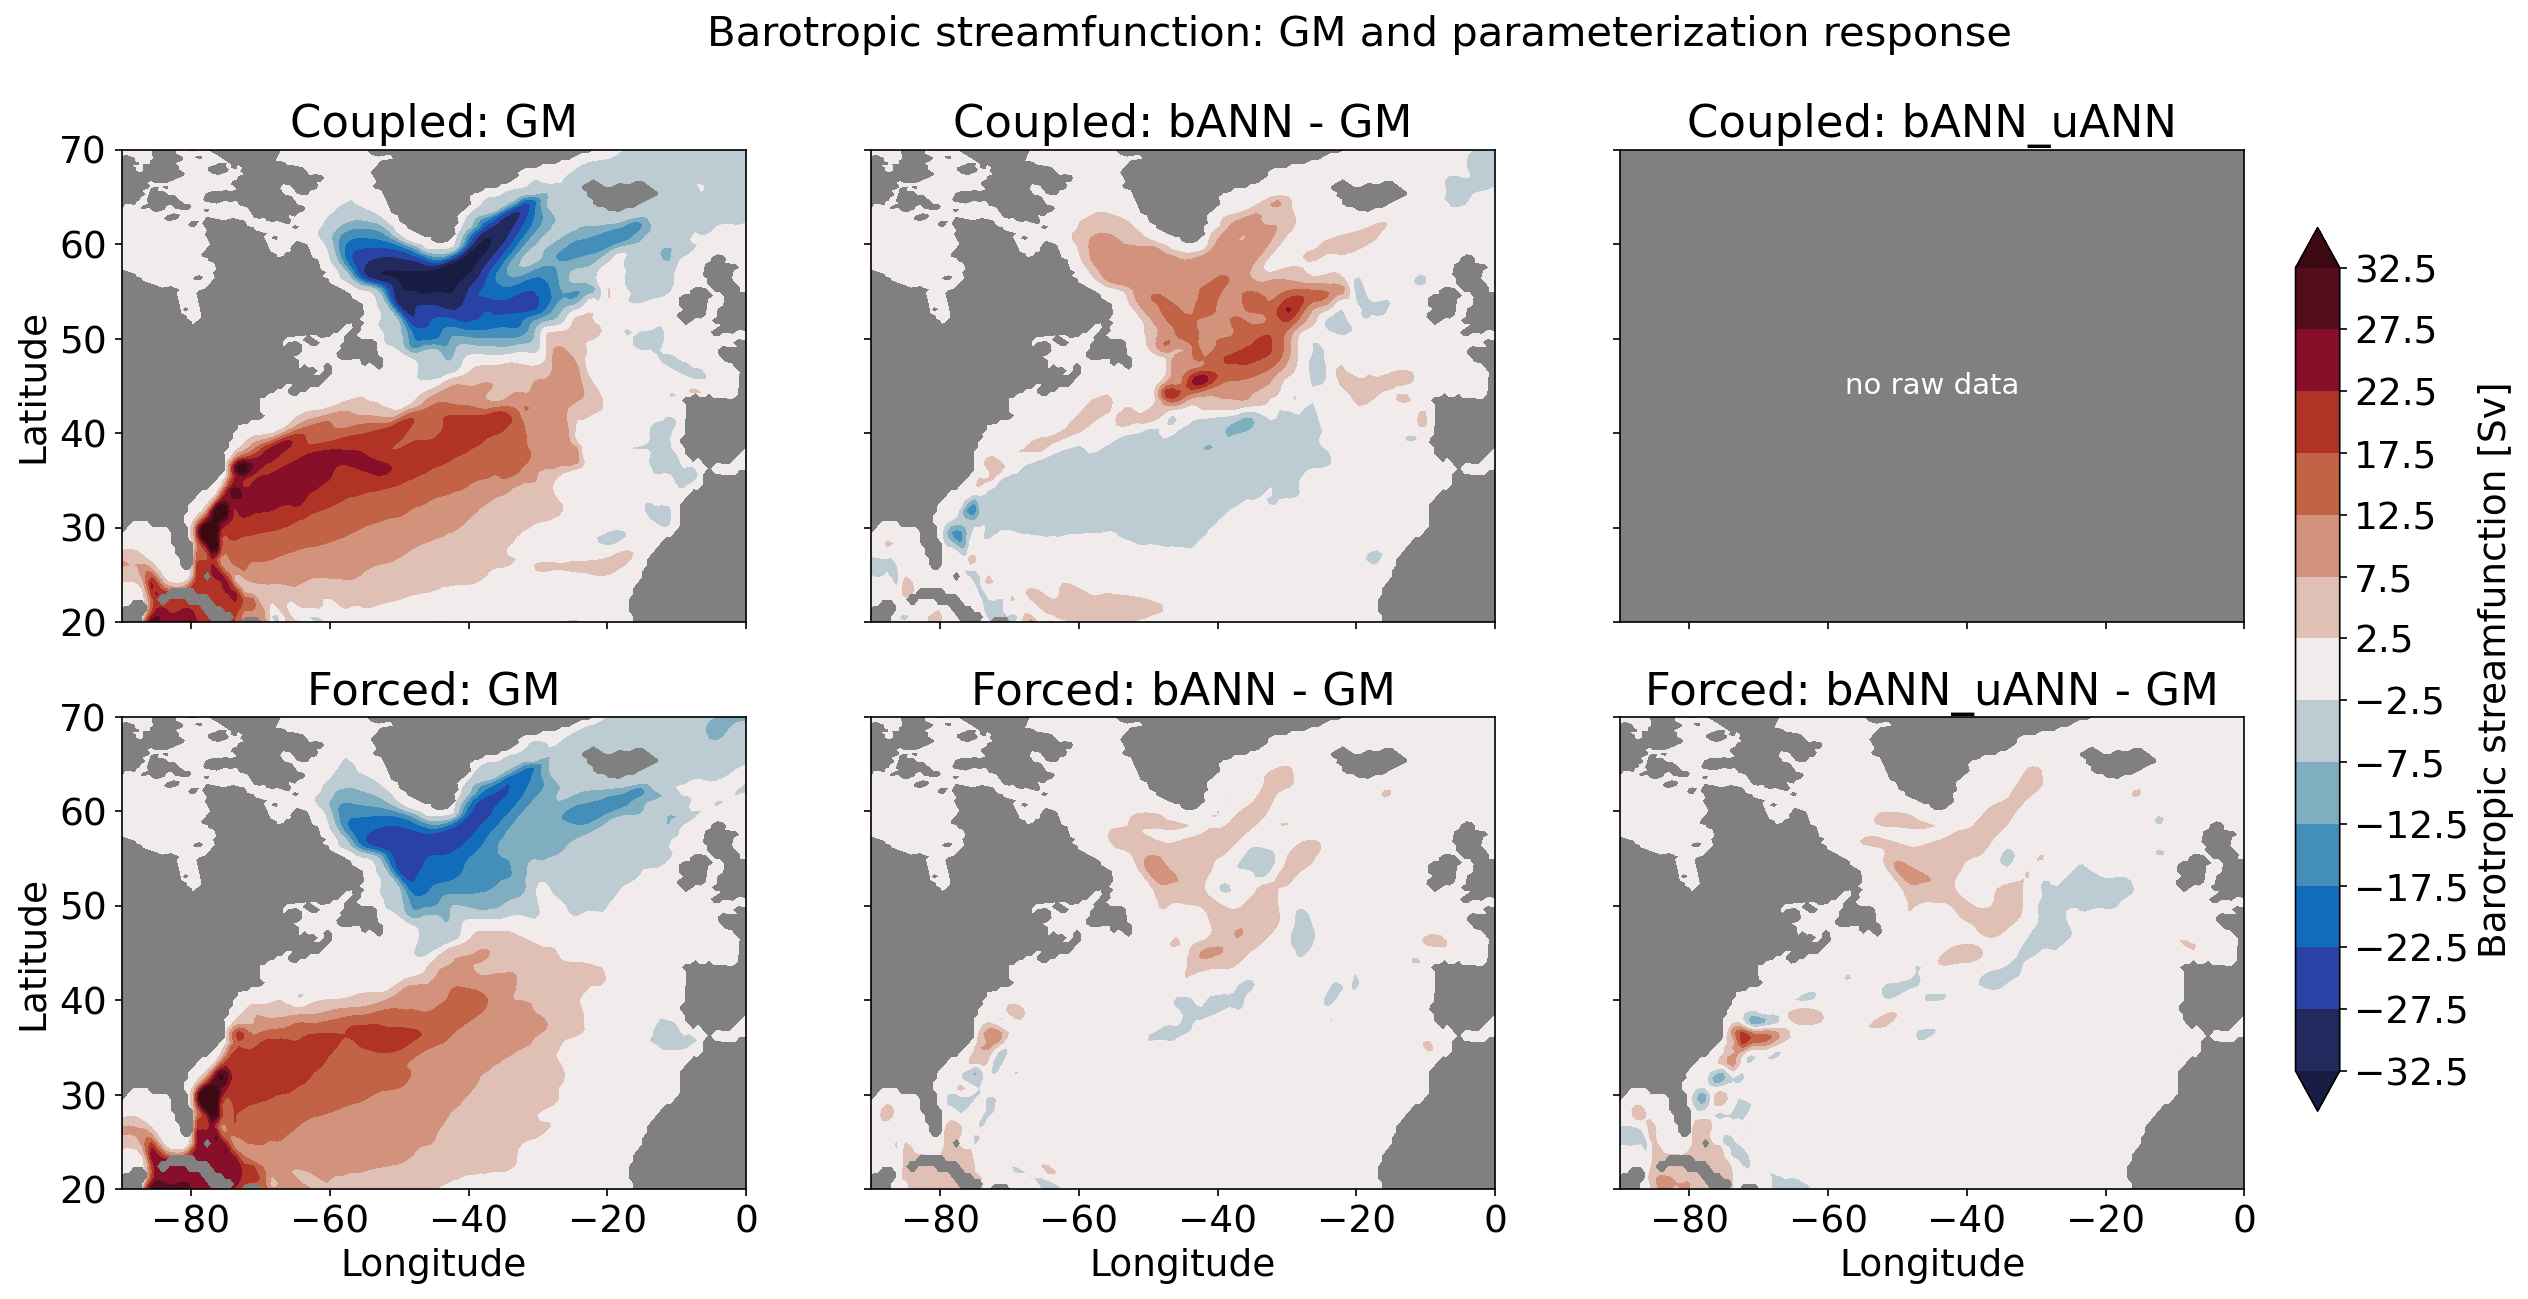

In [84]:
# Barotropic streamfunction: left column = GM (absolute), the two right
# columns = response (experiment - GM). GM is the reference for each row.
# All panels share a single colour scale / colorbar.
BSF_LEVELS = np.arange(-32.5, 35, 5)       # Sv


def _bsf(name):
    """Return (dataset, land-masked barotropic streamfunction) for `name`."""
    ds = exps[name].barotropic_streamfunction()
    psi = ds.psi_barotropic
    grd = exps[name].grd
    wet = xr.DataArray(grd.wet.values > 0, dims=psi.dims)
    return ds, psi.where(wet)


fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    ref_ds, ref_psi = _bsf(names[0])   # GM reference for this regime
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            ds, psi = _bsf(name)
            if col == 0:
                cf = ax.contourf(ds.geolonb, ds.geolatb, psi,
                                 levels=BSF_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]}'
            else:
                cf = ax.contourf(ds.geolonb, ds.geolatb, psi - ref_psi,
                                 levels=BSF_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]} - GM'
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no raw data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
        ax.set_ylim([20, 70])
        ax.set_xlim([-90, 0])
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'Barotropic streamfunction [Sv]',
                 extend='both', shrink=0.85, pad=0.02, ticks=BSF_LEVELS)
fig.suptitle(r'Barotropic streamfunction: GM and parameterization response',
             fontsize=20)
plt.show()

# 6. Mean SSH bias against GLORYS

Validation of the mean SSH against the GLORYS reanalysis (`data/ssh_mean_glorys.nc`,
regular 1&deg; lon/lat `zos`). GLORYS is bilinearly interpolated onto the model's
curvilinear grid (periodic in longitude). SSH has an arbitrary datum, so a common
area-weighted global mean is removed from both fields before differencing.

- **Left column:** GM bias (`GM - GLORYS`).
- **Two right columns:** response (`experiment - GM`).
- **Every panel** is annotated with the area-weighted **global RMSE of that
  experiment's SSH bias vs GLORYS**, so a drop in RMSE from GM to the
  parameterized runs indicates improved skill.


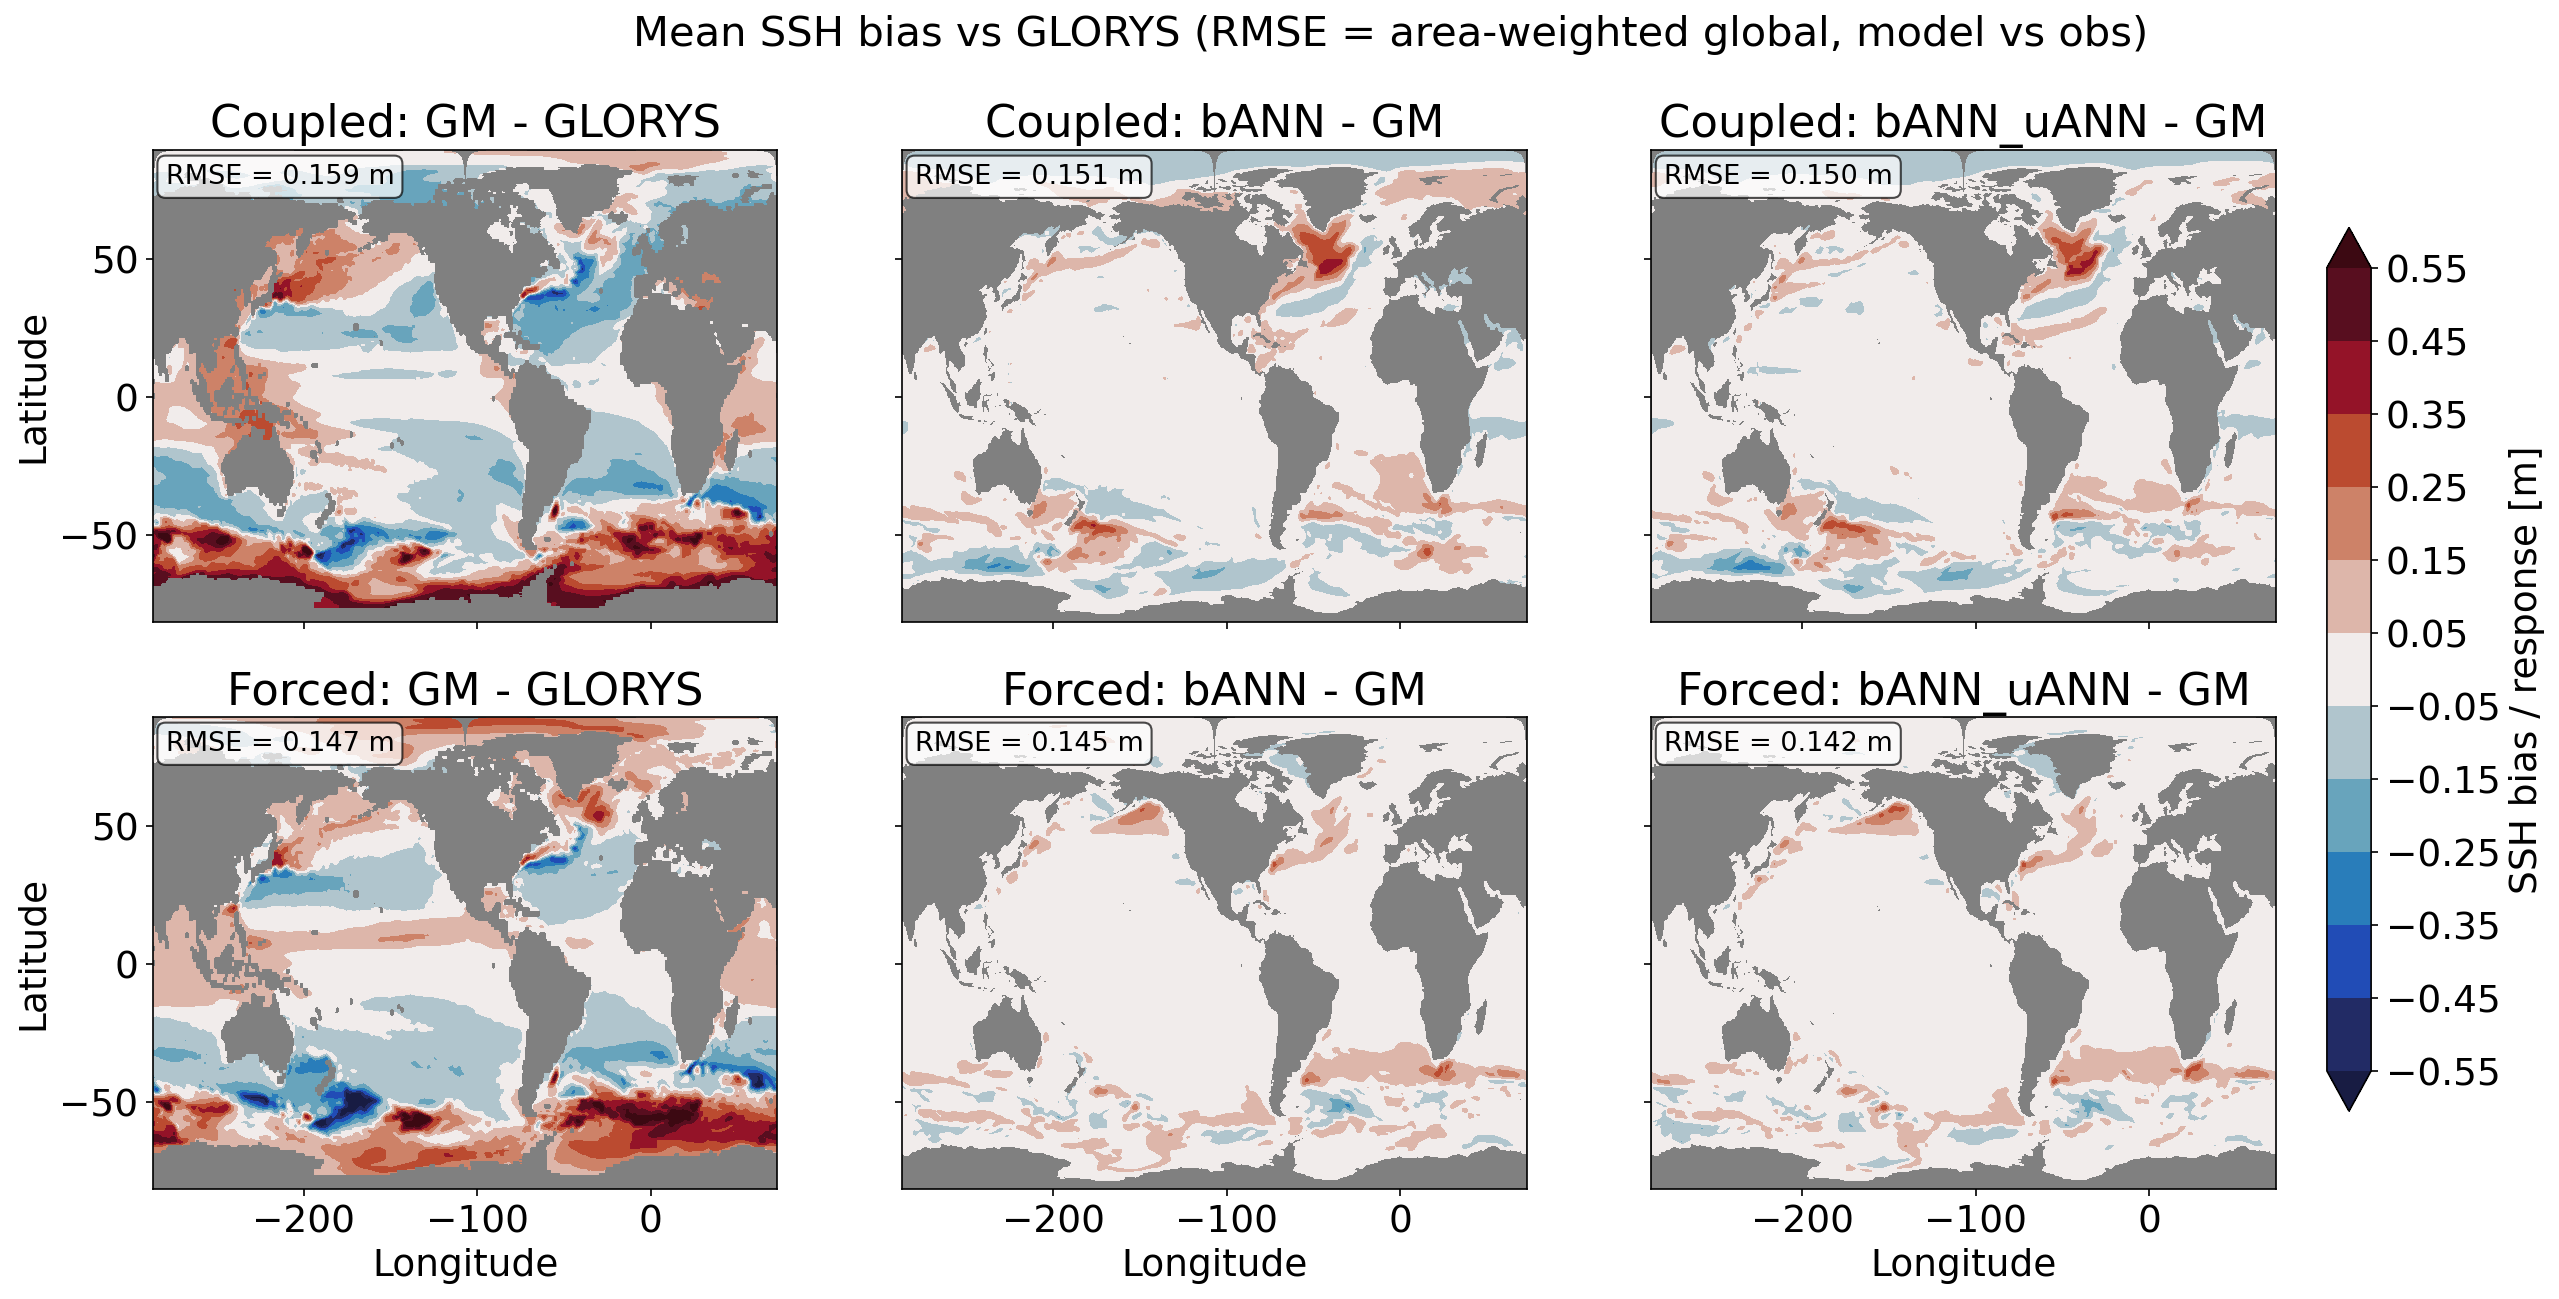

In [92]:
from scipy.interpolate import RegularGridInterpolator


def _glorys_on_model(grd):
    """Interpolate the GLORYS mean SSH (regular lon/lat) onto the model's
    curvilinear (geolon, geolat) grid. Longitude is padded periodically so the
    interpolation wraps across the dateline."""
    g = xr.open_dataset(os.path.join(REPO, 'data', 'ssh_mean_glorys.nc'))
    lat = g.yh.values
    lon = g.xh.values
    zos = g.zos.values                              # (lat, lon)
    lon_ext = np.concatenate([[lon[-1] - 360.0], lon, [lon[0] + 360.0]])
    zos_ext = np.concatenate([zos[:, -1:], zos, zos[:, :1]], axis=1)
    interp = RegularGridInterpolator((lat, lon_ext), zos_ext,
                                     bounds_error=False, fill_value=np.nan)
    glon = ((grd.geolon.values + 180.0) % 360.0) - 180.0
    glat = grd.geolat.values
    obs = interp(np.stack([glat.ravel(), glon.ravel()], axis=-1)).reshape(glon.shape)
    return xr.DataArray(obs, dims=grd.geolon.dims)


# The model grid is identical for every experiment: interpolate GLORYS once.
GRID = exps[coupled_names[0]].grd
OBS_SSH = _glorys_on_model(GRID)
AREA = exps[coupled_names[0]].area.fillna(0.0)


def _ssh_masked(name):
    return exps[name].ssh()['mean_ssh'].where(GRID.wet.values > 0)


def _remove_mean(field, valid):
    """Remove the area-weighted mean over `valid` (SSH has an arbitrary datum)."""
    return field - field.where(valid).weighted(AREA).mean(('yh', 'xh'))


def _ssh_bias(name):
    """Model - GLORYS mean SSH, with a common global offset removed."""
    field = _ssh_masked(name)
    valid = field.notnull() & OBS_SSH.notnull()
    return _remove_mean(field, valid) - _remove_mean(OBS_SSH, valid), valid


def _rmse(bias, valid):
    """Area-weighted global RMSE of a (already offset-removed) bias field [m]."""
    return float(np.sqrt((bias ** 2).where(valid).weighted(AREA).mean(('yh', 'xh'))))


# Left column: GM bias vs GLORYS. Right columns: response (experiment - GM).
# RMSE (annotated in every panel) is the area-weighted global RMSE of that
# experiment's SSH bias vs GLORYS, so the skill change is comparable across
# columns even though the right panels display the response.
# All panels share a single colour scale / colorbar.
SSH_LEVELS = np.arange(-0.55, 0.6, 0.1)      # m

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    ref_valid = _ssh_masked(names[0]).notnull() & OBS_SSH.notnull()
    ref_ssh0 = _remove_mean(_ssh_masked(names[0]), ref_valid)
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            bias, valid = _ssh_bias(name)
            rmse = _rmse(bias, valid)
            if col == 0:
                cf = ax.contourf(GRID.geolon, GRID.geolat, bias,
                                 levels=SSH_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]} - GLORYS'
            else:
                field = _ssh_masked(name)
                resp = _remove_mean(field, field.notnull() & ref_valid) - ref_ssh0
                cf = ax.contourf(GRID.geolon, GRID.geolat, resp,
                                 levels=SSH_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]} - GM'
            ax.text(0.02, 0.97, f'RMSE = {rmse:.3f} m', transform=ax.transAxes,
                    va='top', ha='left', fontsize=13,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'SSH bias / response [m]',
                 extend='both', shrink=0.85, pad=0.02, ticks=SSH_LEVELS)
fig.suptitle(r'Mean SSH bias vs GLORYS (RMSE = area-weighted global, model vs obs)',
             fontsize=20)
plt.show()

# 7. SSH variability (std) bias against altimeter

Validation of the SSH *variability* against the altimeter product
(`data/ssh_std_obs.nc`, regular 1&deg; lon/lat `adt` = SSH standard deviation).
The model std is `sqrt(ssh_variance)` (from the same `*_SSH.nc` files as the
mean SSH); the observed std is interpolated onto the model's curvilinear grid.
Standard deviation is an absolute quantity, so no datum offset is removed.

- **Left column:** GM bias (`GM - obs`).
- **Two right columns:** response (`experiment - GM`).
- **Every panel** is annotated with the area-weighted **global RMSE of that
  experiment's std bias vs obs**.


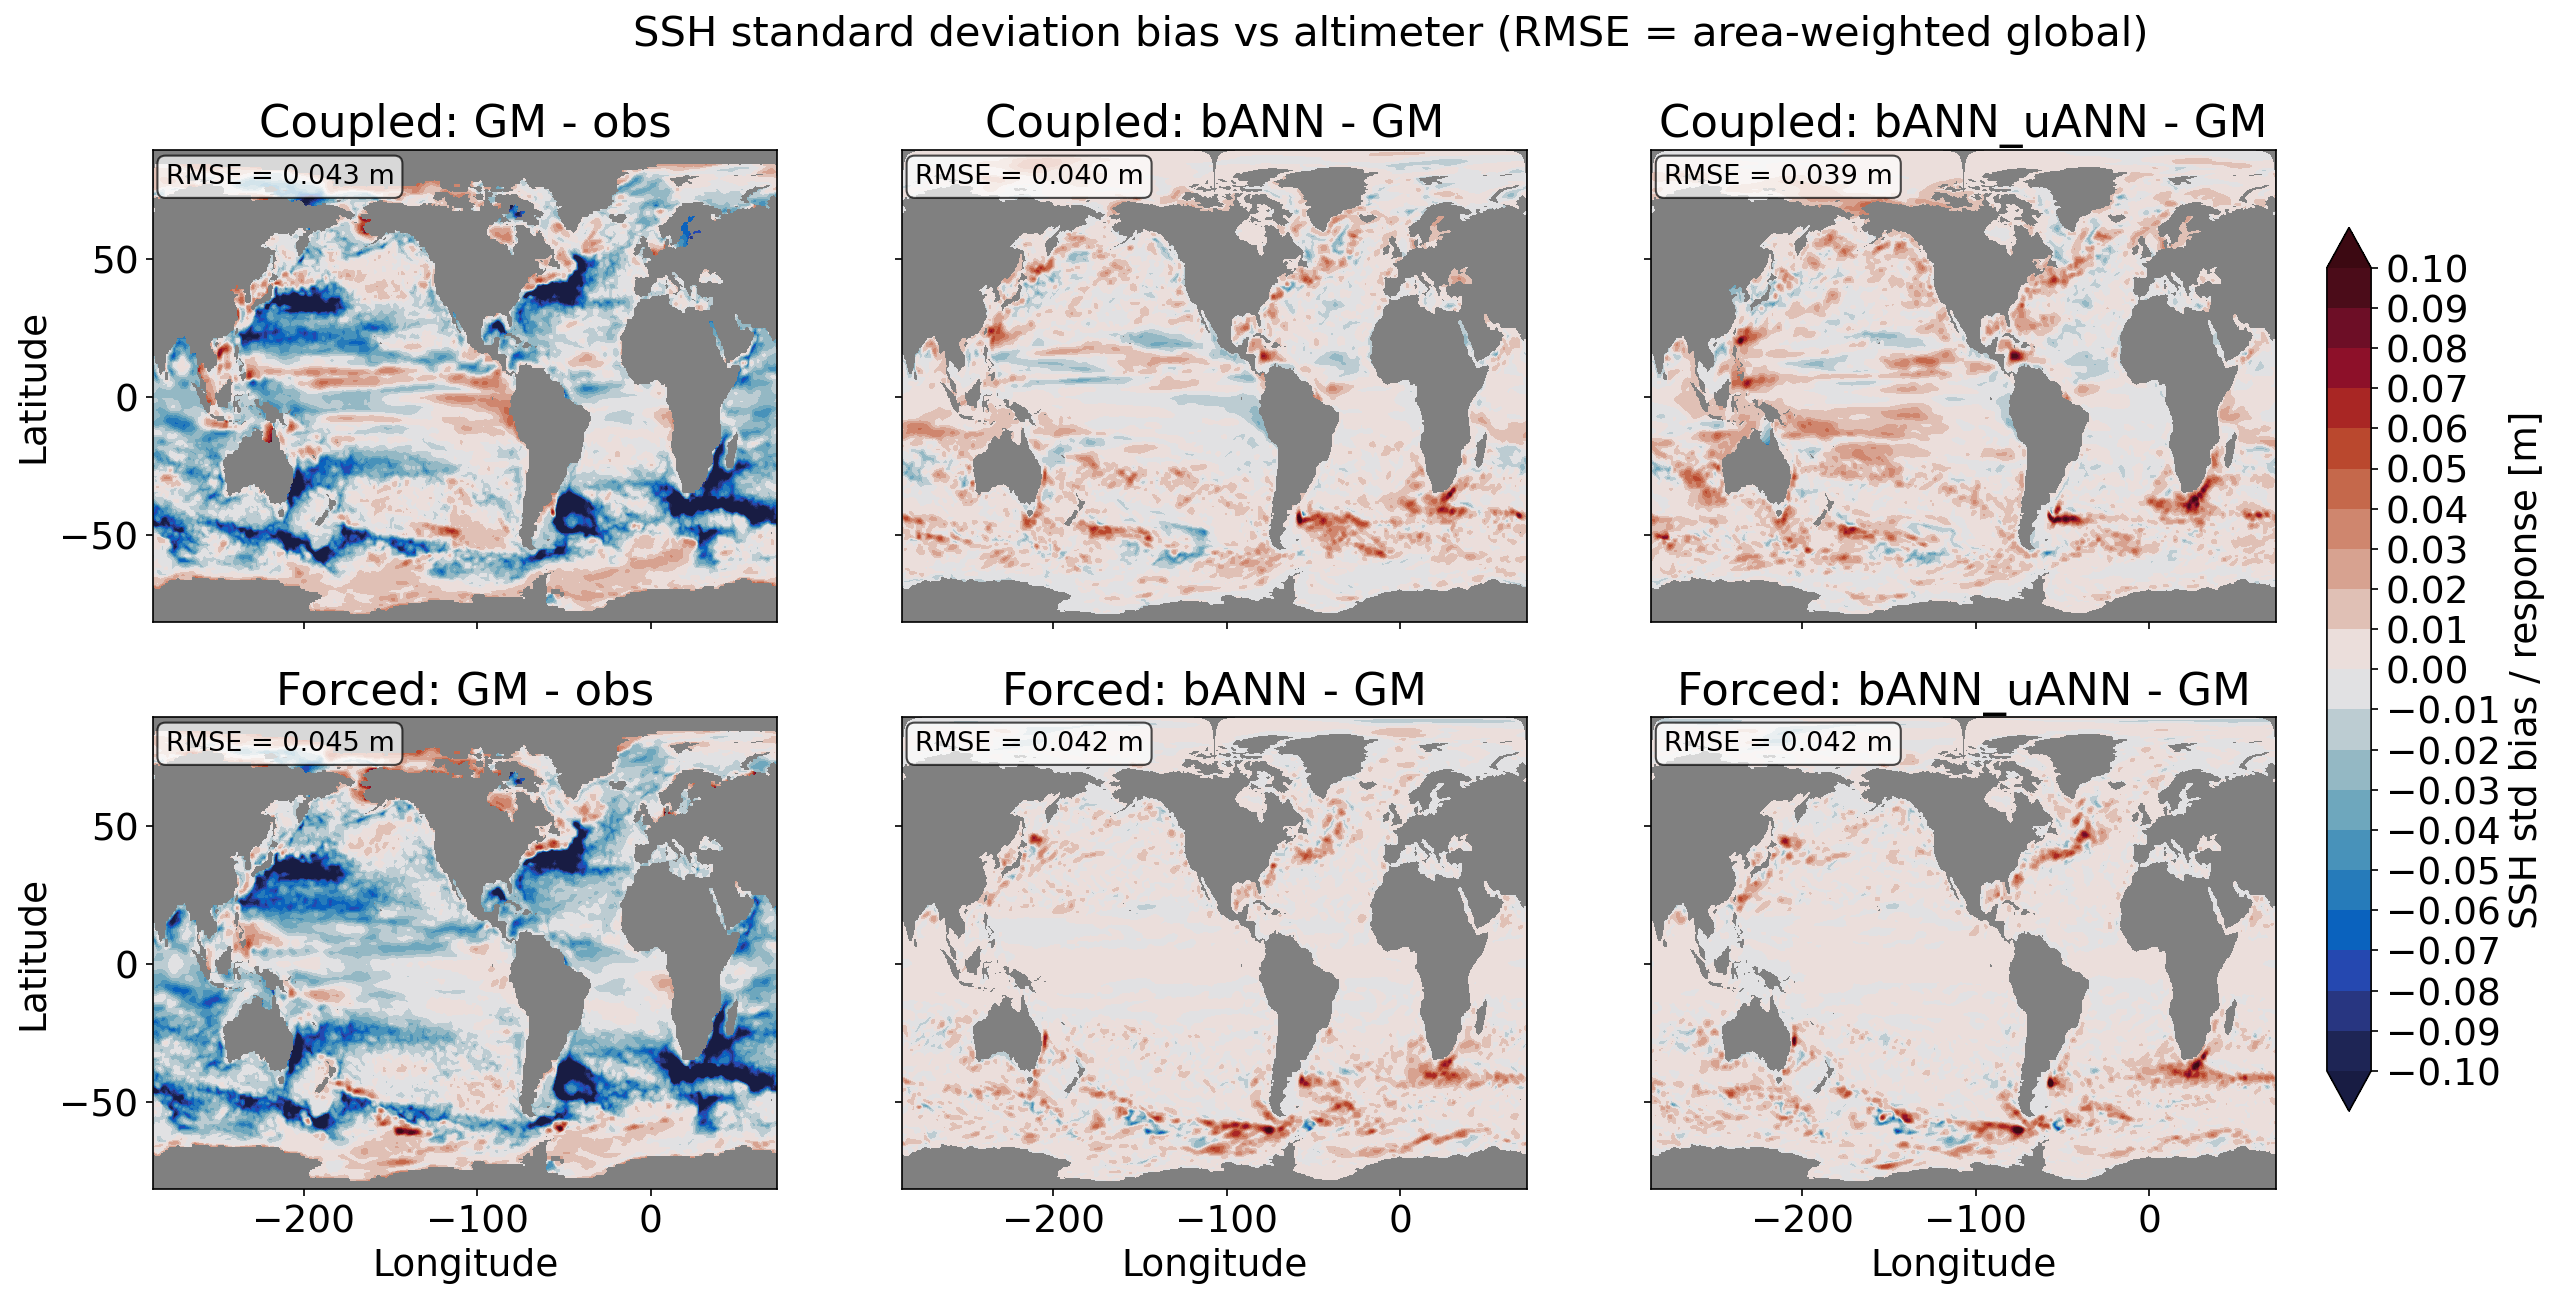

In [111]:
# SSH standard deviation vs altimeter observations.
# Model std = sqrt(ssh_variance); obs std = `adt` from data/ssh_std_obs.nc.
# Std is an absolute quantity, so (unlike the mean SSH) no datum offset is
# removed. Left column = GM bias (GM - obs); right columns = response
# (experiment - GM). Every panel is annotated with the area-weighted global
# RMSE of that experiment's std bias vs obs. All panels share one colorbar.


def _obs_std_on_model(grd):
    """Interpolate the altimeter SSH std (regular lon/lat `adt`) onto the
    model's curvilinear grid. Model longitudes are mapped to [0, 360) to match
    the obs grid, which is padded periodically so the interpolation wraps."""
    o = xr.open_dataset(os.path.join(REPO, 'data', 'ssh_std_obs.nc'))
    lat = o.lat.values
    lon = o.lon.values
    adt = o.adt.values                              # (lat, lon), std [m]
    lon_ext = np.concatenate([[lon[-1] - 360.0], lon, [lon[0] + 360.0]])
    adt_ext = np.concatenate([adt[:, -1:], adt, adt[:, :1]], axis=1)
    interp = RegularGridInterpolator((lat, lon_ext), adt_ext,
                                     bounds_error=False, fill_value=np.nan)
    glon = grd.geolon.values % 360.0
    glat = grd.geolat.values
    obs = interp(np.stack([glat.ravel(), glon.ravel()], axis=-1)).reshape(glon.shape)
    return xr.DataArray(obs, dims=grd.geolon.dims)


OBS_STD = _obs_std_on_model(GRID)


def _ssh_std(name):
    """Model SSH standard deviation on the T-grid [m], land-masked."""
    var = exps[name].ssh()['ssh_variance'].where(GRID.wet.values > 0)
    return np.sqrt(var)


STD_LEVELS = np.arange(-0.1, 0.11, 0.01)     # m

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    ref_std = _ssh_std(names[0])   # GM reference std for this regime
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        try:
            std = _ssh_std(name)
            bias = std - OBS_STD
            valid = std.notnull() & OBS_STD.notnull()
            rmse = _rmse(bias, valid)
            if col == 0:
                cf = ax.contourf(GRID.geolon, GRID.geolat, bias,
                                 levels=STD_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]} - obs'
            else:
                cf = ax.contourf(GRID.geolon, GRID.geolat, std - ref_std,
                                 levels=STD_LEVELS,
                                 cmap=cmocean.cm.balance, extend='both')
                title = f'{regime}: {LABELS[name]} - GM'
            ax.text(0.02, 0.97, f'RMSE = {rmse:.3f} m', transform=ax.transAxes,
                    va='top', ha='left', fontsize=13,
                    bbox=dict(boxstyle='round', fc='white', alpha=0.7))
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'SSH std bias / response [m]',
                 extend='both', shrink=0.85, pad=0.02, ticks=STD_LEVELS)
fig.suptitle(r'SSH standard deviation bias vs altimeter (RMSE = area-weighted global)',
             fontsize=20)
plt.show()


# 8. SST variability (detrended, deseasonalised std)

Maps of sea-surface temperature *variability*. For each experiment `thetao` is
read from the z-coordinate history (`*.mom6.h.z.*`), the uppermost level is kept
as SST, and over the standard averaging window the series at each grid point is
(1) linearly detrended (`a + b t` removed), (2) deseasonalised (monthly
climatology removed), and (3) reduced to its temporal standard deviation
(`Experiment.compute_sst_std`).

- **Left column:** GM absolute std.
- **Two right columns:** response (`experiment - GM`).

Observational reference SST variability to be added later.


In [6]:
# Compute (and cache) the detrended, deseasonalised SST std for every
# experiment. Reads raw z-coordinate history -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_sst_std()
    except Exception as e:
        print(f'{name} skipped ({e})')


[########################################] | 100% Completed | 33.27 s
[########################################] | 100% Completed | 76.73 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
forced_CTRL skipped (NetCDF: Not a valid ID)
[########################################] | 100% Completed | 83.83 s
[########################################] | 100% Completed | 77.54 s


In [9]:
exps['forced_CTRL'].compute_sst_std()

[########################################] | 100% Completed | 73.01 s


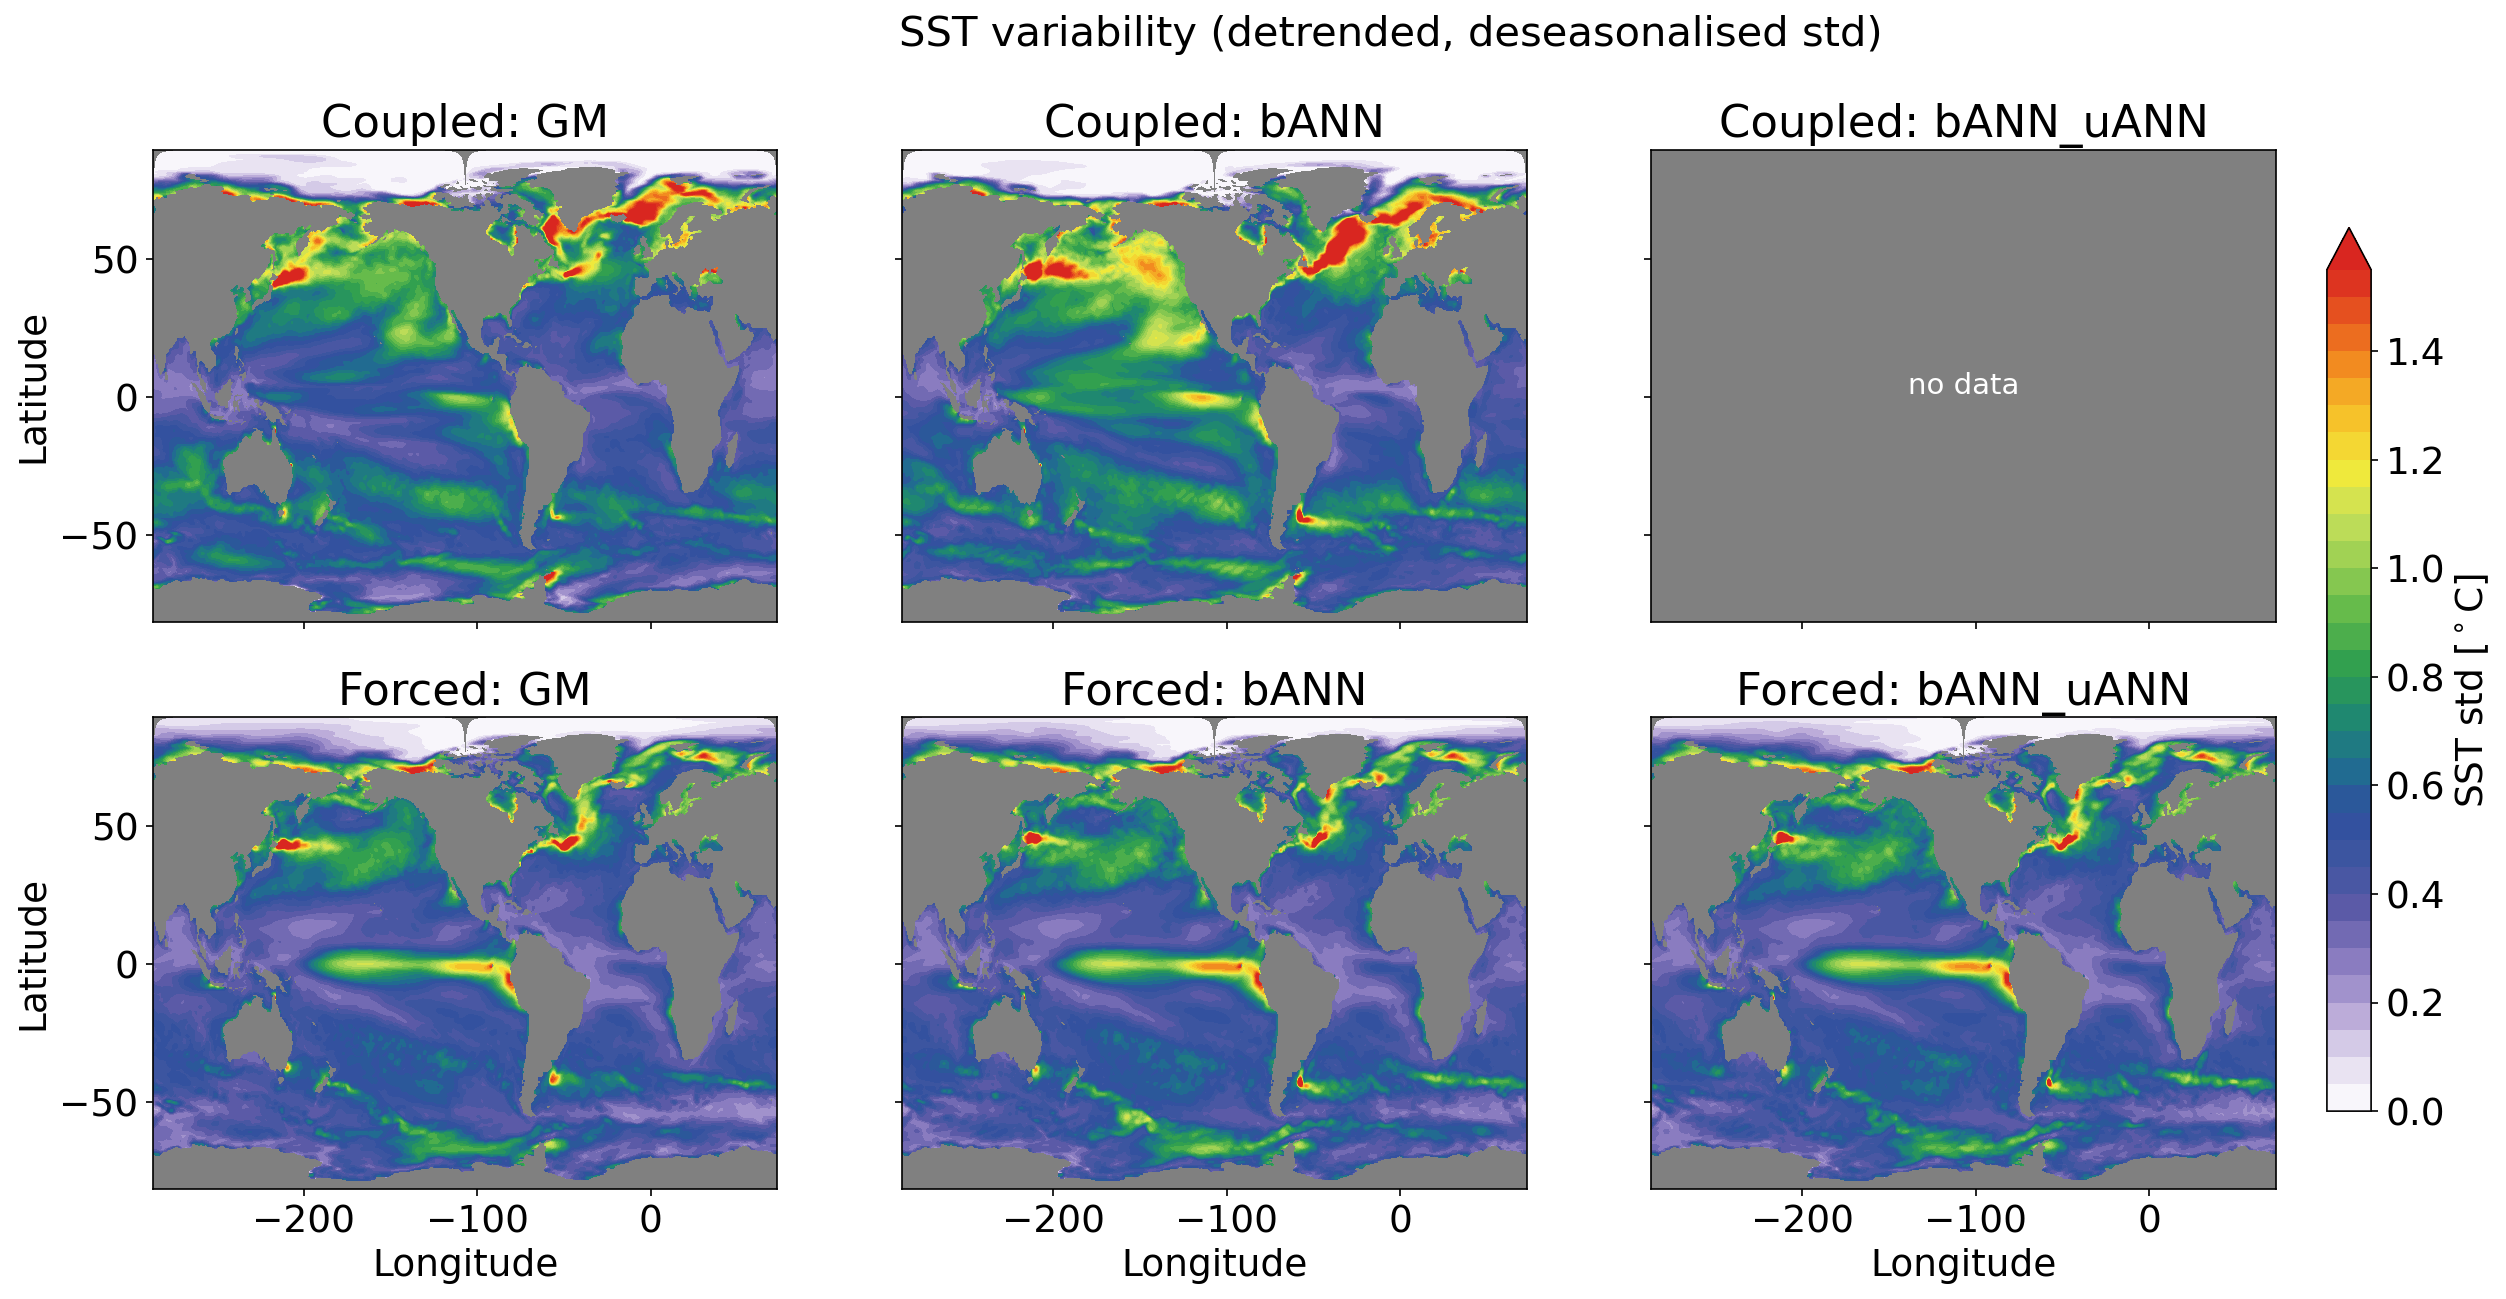

In [51]:
# SST variability (absolute std only): every panel shows the detrended,
# deseasonalised SST std for that experiment. Rows = regime, columns =
# GM / bANN / bANN_uANN. Single shared sequential colorbar.

# NCL-style White-Violet-Blue-Green-Yellow-Orange-Red palette.
from matplotlib.colors import LinearSegmentedColormap
WhViBlGrYeOrRe = LinearSegmentedColormap.from_list('WhViBlGrYeOrRe', [
    '#ffffff', '#e3dcef', '#b6a5d6', '#8a7cc0', '#5d5aa8',
    '#3f56a0', '#2f4f9e', '#1f6f8f', '#1f8a6e', '#2f9e4f',
    '#5fb84a', '#93cd52', '#c6e05a', '#f2ea3a', '#f6c22a',
    '#f39320', '#e85a1f', '#d92620',
])

SST_STD_LEVELS = np.arange(0.0, 1.6, 0.05)        # degC, absolute std

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf_abs = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            std = _sst_std(name)
            cf_abs = ax.contourf(grd.geolon, grd.geolat, std,
                                 levels=SST_STD_LEVELS,
                                 cmap=WhViBlGrYeOrRe, extend='max')
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
        ax.set_title(f'{regime}: {LABELS[name]}')
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf_abs is not None:
    fig.colorbar(cf_abs, ax=axes, label=r'SST std [$^\circ$C]',
                 extend='max', shrink=0.85, pad=0.02)
fig.suptitle(r'SST variability (detrended, deseasonalised std)', fontsize=20)
plt.show()


# 9. Leading EOF of SST variability (area-weighted)

Leading Empirical Orthogonal Function of the same detrended, deseasonalised
SST anomalies used for the SST std (Section 8). The decomposition **accounts
for the grid-cell area**: each anomaly is weighted by $\sqrt{A_i}$ before the
SVD, so the spatial patterns are orthogonal with respect to the inner product
on the sphere,

$$\langle u, v\rangle = \sum_i A_i\, u_i\, v_i .$$

The physical patterns $e_k = v_k / \sqrt{A_i}$ then satisfy
$\sum_i A_i\, e_k(i)\, e_l(i) = \delta_{kl}$. The leading principal component
(PC1) is standardised to unit variance, and the map (`sst_eof1`) is the
regression of the anomalies onto PC1 (degC per +1 std of PC1). Both the pattern
and the PC1 time series are cached to `<folder>/<name>_sst_eof1.nc`; the panel
titles show the fraction of area-weighted variance explained.

The first cell computes/caches per experiment; the second plots the six EOF1
maps and the PC1 time series.


In [52]:
# Compute (and cache) the leading area-weighted EOF / PC1 of the detrended,
# deseasonalised SST for every experiment. Reads raw z-coordinate history
# -> heavy; skips cached / missing.
for name in exp_names:
    exp = exps[name]
    try:
        exp.compute_sst_eof1()
    except Exception as e:
        print(f'{name} skipped ({e})')


[########################################] | 100% Completed | 12.51 s
[########################################] | 100% Completed | 66.44 s
coupled_bANN_1.0_uANN_1.0 skipped (no files to open)
[########################################] | 100% Completed | 60.20 s
[########################################] | 100% Completed | 52.50 s
[########################################] | 100% Completed | 43.15 s


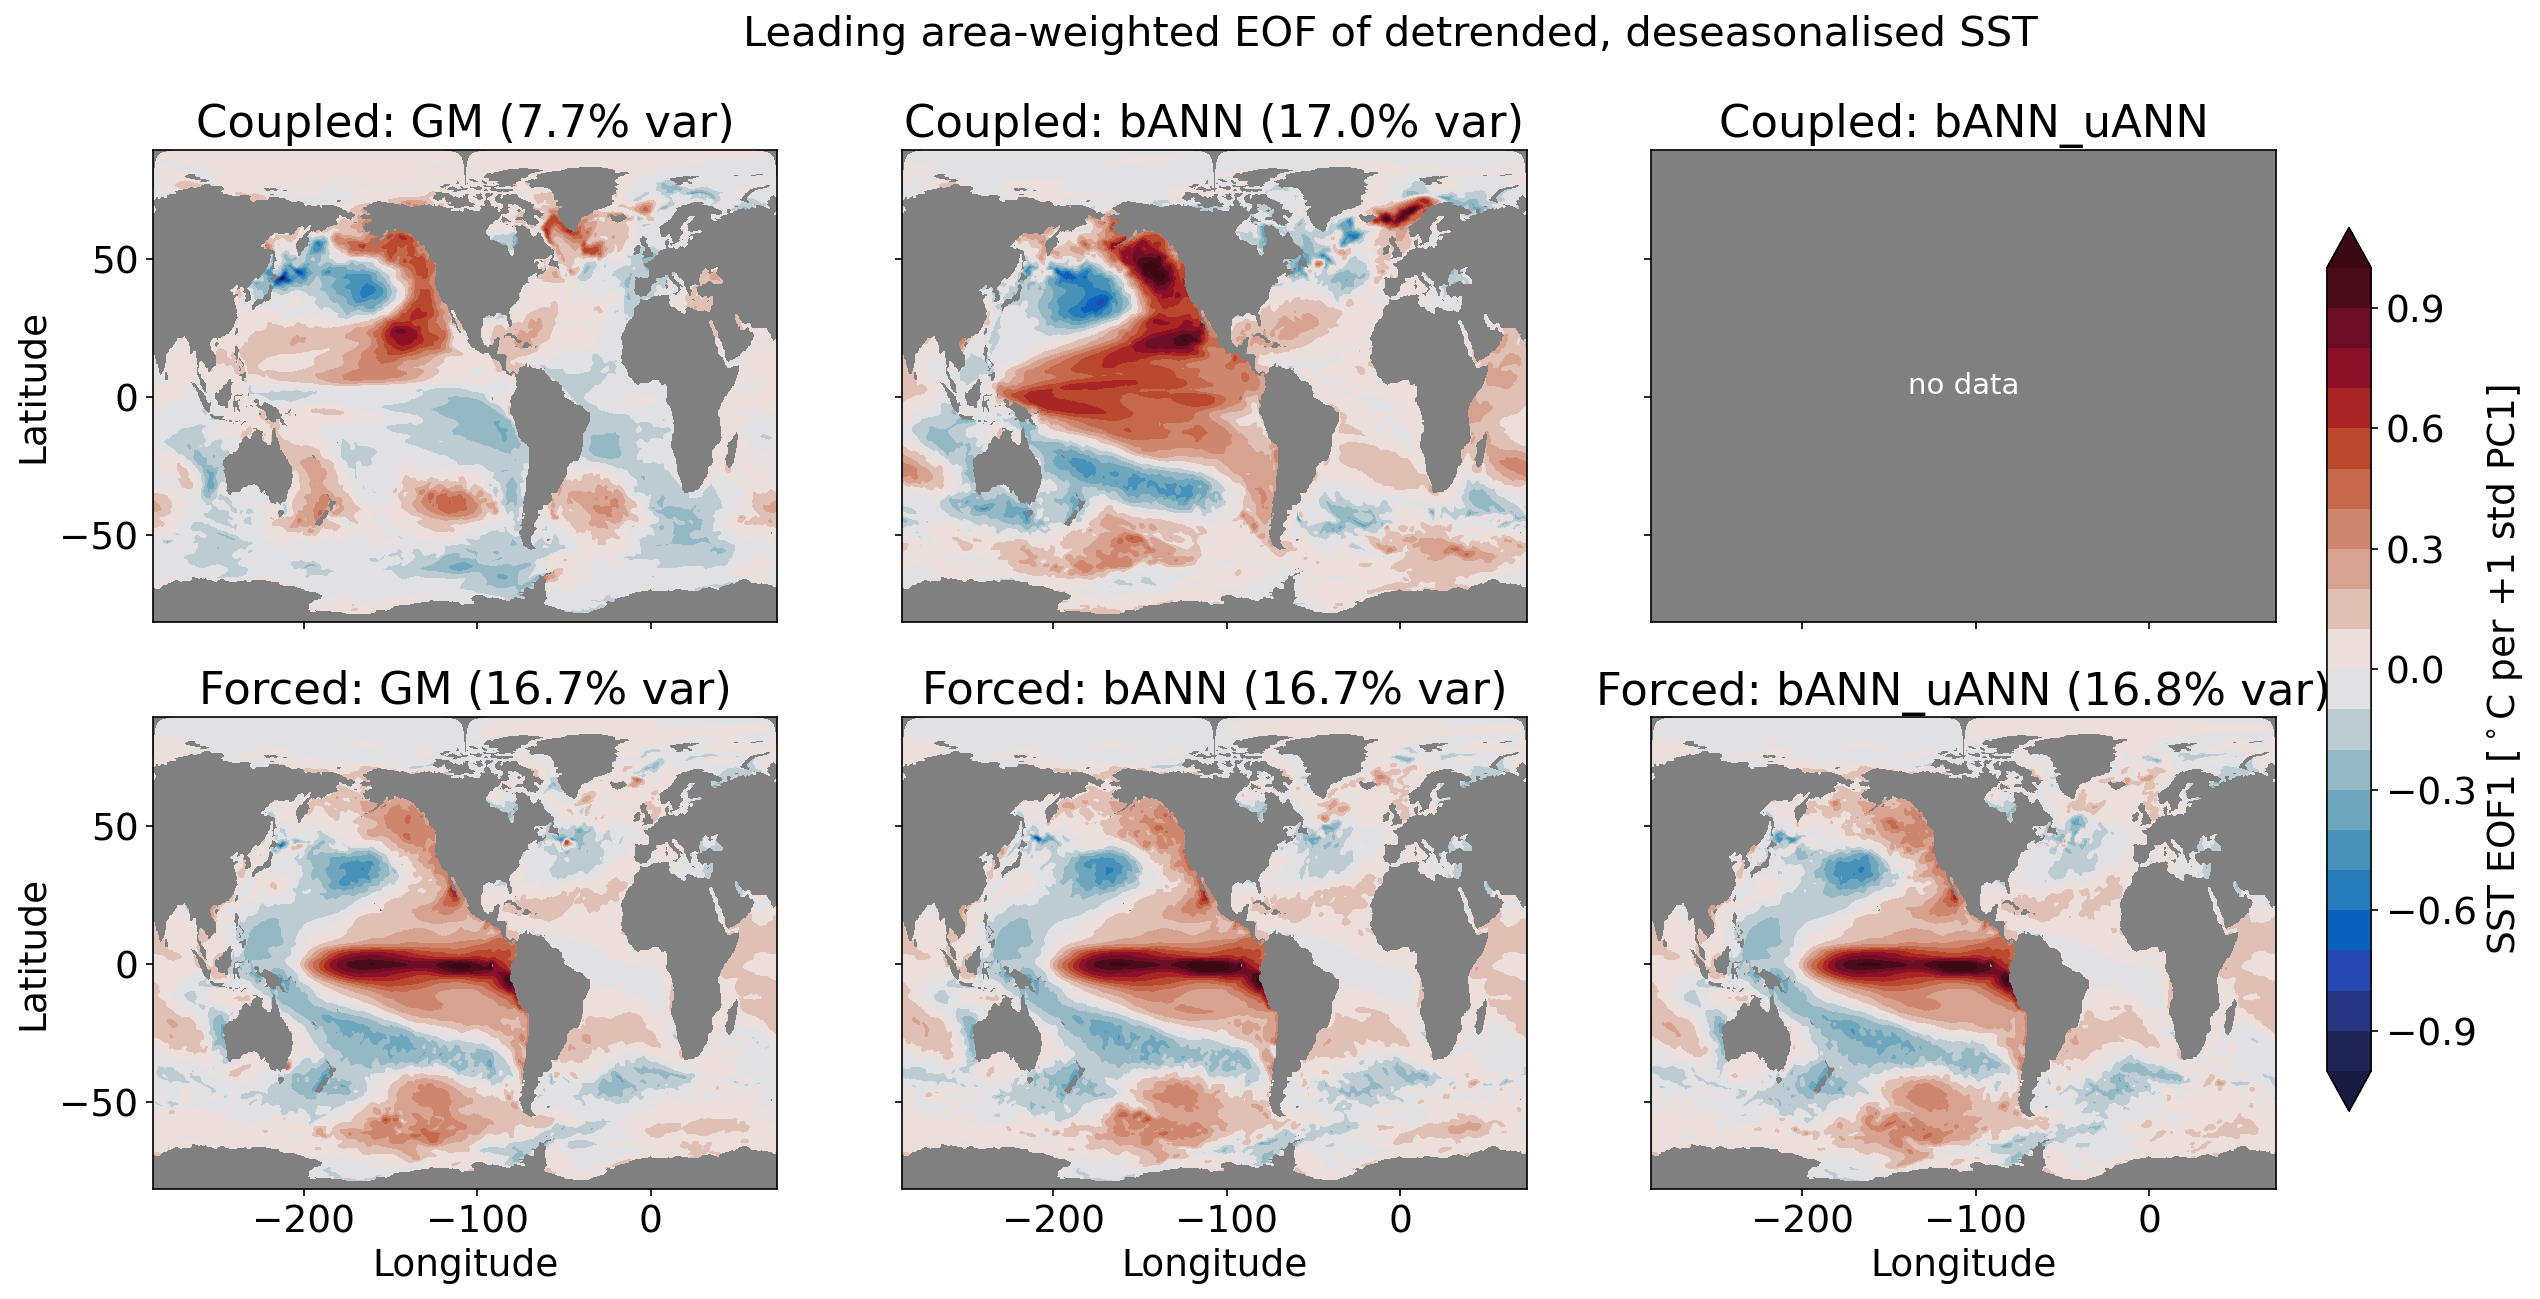

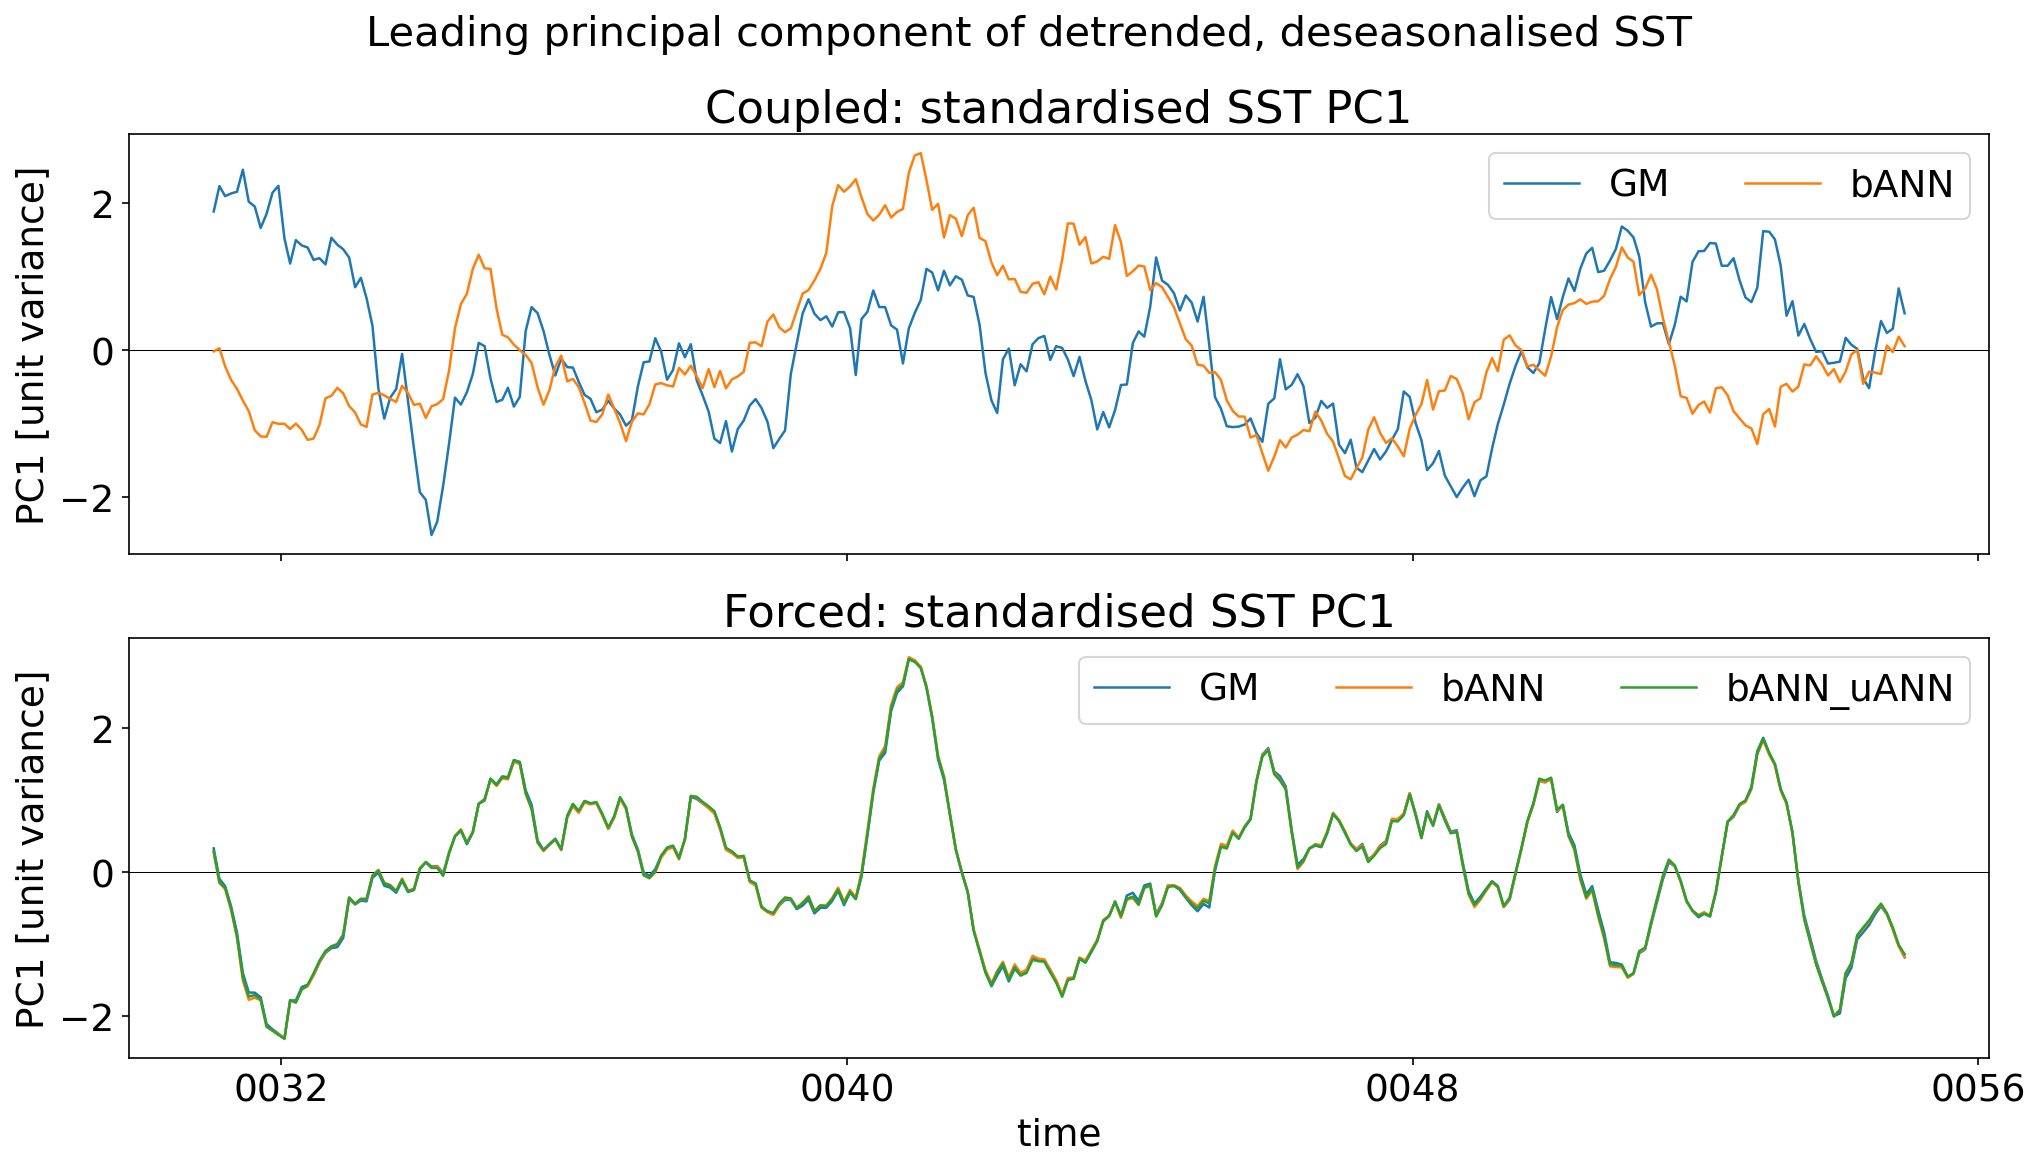

In [53]:
# Leading area-weighted EOF of the detrended, deseasonalised SST anomalies.
# The spatial patterns are orthogonal under the spherical inner product
# (area-weighted); the map shows degC per +1 std of the standardised PC1.
EOF_LEVELS = np.arange(-1.0, 1.05, 0.1)      # degC per +1 std of PC1

fig, axes = plt.subplots(2, 3, figsize=(22, 9), dpi=150,
                         sharex=True, sharey=True)
cf = None
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    for col, name in enumerate(names):
        ax = axes[row, col]
        ax.set_facecolor('gray')
        grd = exps[name].grd
        try:
            ds = exps[name].sst_eof1()
            eof = ds['sst_eof1'].where(grd.wet.values > 0)
            ev = float(ds['sst_eof1'].attrs.get('explained_variance', np.nan))
            cf = ax.contourf(grd.geolon, grd.geolat, eof, levels=EOF_LEVELS,
                             cmap=cmocean.cm.balance, extend='both')
            title = f'{regime}: {LABELS[name]} ({100 * ev:.1f}% var)'
        except (FileNotFoundError, KeyError):
            ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                    transform=ax.transAxes, color='white', fontsize=14)
            title = f'{regime}: {LABELS[name]}'
        ax.set_title(title)
        ax.set_xlabel('Longitude' if row == 1 else '')
        ax.set_ylabel('Latitude' if col == 0 else '')
if cf is not None:
    fig.colorbar(cf, ax=axes, label=r'SST EOF1 [$^\circ$C per +1 std PC1]',
                 extend='both', shrink=0.85, pad=0.02)
fig.suptitle(r'Leading area-weighted EOF of detrended, deseasonalised SST',
             fontsize=20)
plt.show()

# Standardised leading principal component (PC1) time series.
fig, axes = plt.subplots(2, 1, figsize=(16, 8), dpi=150, sharex=True)
for row, (regime, names) in enumerate([('Coupled', coupled_names),
                                       ('Forced', forced_names)]):
    ax = axes[row]
    ax.axhline(0.0, color='k', lw=0.5)
    for name in names:
        try:
            ds = exps[name].sst_eof1()
            ax.plot(ds['time'], ds['sst_pc1'], lw=1.2, label=LABELS[name])
        except (FileNotFoundError, KeyError):
            pass
    ax.set_title(f'{regime}: standardised SST PC1')
    ax.set_ylabel('PC1 [unit variance]')
    ax.legend(loc='upper right', ncol=3)
axes[1].set_xlabel('time')
fig.suptitle(r'Leading principal component of detrended, deseasonalised SST',
             fontsize=20)
plt.show()
